In [1]:
!pip install scikit-learn pandas numpy

In [2]:
# ============================================================
# CELL 2 — Import libraries
# ============================================================
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


In [3]:
import zipfile

zip_path = '/content/dataset_csv.zip'
extract_path = '/content/dataset_csv'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [4]:
# ============================================================
# CELL 3 — SET YOUR PATHS HERE  (only change these lines)
# ============================================================

DS1_PATH   = r'/content/Sepsis_Working_Dataset.csv'
DS2_PATH   = r'/content/sepsis.csv'
DS3_FOLDER = r'/content/dataset_csv'
OUTPUT_DIR = 'processed_data/'

PREDICTION_HORIZON = 15
MIN_HISTORY_HOURS  = 6

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Column definitions ──────────────────────────────────────
# SOFA and Apache from DS1 are NOT included — reserved for XAI validation only.

VITAL_COLS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

LAB_COLS = [
    'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2',
    'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
    'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
    'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb',
    'PTT', 'WBC', 'Fibrinogen', 'Platelets'
]

DEMO_COLS        = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']
LABEL_COL        = 'SepsisLabel'
ALL_FEATURE_COLS = VITAL_COLS + LAB_COLS + DEMO_COLS   # 40 features

# ── Verified feature index map ──────────────────────────────
# Indices are positions in ALL_FEATURE_COLS (0-based)
# Used by TimeGAN ClinicalConstraintLoss and Stage 6 XAI CAS
FEAT = {
    'HR'              : 0,
    'O2Sat'           : 1,
    'Temp'            : 2,
    'SBP'             : 3,
    'MAP'             : 4,
    'DBP'             : 5,
    'Resp'            : 6,
    'FiO2'            : 10,
    'PaCO2'           : 12,
    'SaO2'            : 13,
    'BUN'             : 15,
    'Creatinine'      : 19,  # FIX: was incorrectly 20
    'Bilirubin_direct': 20,
    'Lactate'         : 22,
    'Bilirubin_total' : 26,
    'Hct'             : 28,
    'Hgb'             : 29,
    'WBC'             : 31,
    'Platelets'       : 33,
}

# ── SOFA-aligned features for XAI Clinical Alignment Score ──
# SOFA domains: respiratory (FiO2/PaO2/SaO2), coagulation (Platelets),
# liver (Bilirubin), cardiovascular (MAP), renal (Creatinine/BUN),
# plus key sepsis biomarkers (Lactate, WBC)
SOFA_FEATURE_NAMES = [
    'FiO2', 'PaCO2', 'SaO2', 'Platelets', 'Bilirubin_direct',
    'Bilirubin_total', 'MAP', 'Creatinine', 'BUN', 'Lactate', 'WBC', 'Hct', 'Hgb'
]
SOFA_FEAT_IDX = [FEAT[f] for f in SOFA_FEATURE_NAMES]

print(f'Output folder     : {OUTPUT_DIR}')
print(f'Prediction window : {PREDICTION_HORIZON} hours')
print(f'Total features    : {len(ALL_FEATURE_COLS)}')
print(f'SOFA indices (for CAS): {SOFA_FEAT_IDX}')
# Verify index assignments are correct
for name, idx in FEAT.items():
    assert ALL_FEATURE_COLS[idx] == name, f'Index mismatch: {name} expected {idx}, got {ALL_FEATURE_COLS.index(name)}'
print('Feature index verification PASSED.')

Output folder     : processed_data/
Prediction window : 15 hours
Total features    : 40
SOFA indices (for CAS): [10, 12, 13, 33, 20, 26, 4, 19, 15, 22, 31, 28, 29]
Feature index verification PASSED.


In [5]:
# ============================================================
# CELL 4 — Load Dataset 1  (static, for XAI only)
# ============================================================
import os, pandas as pd
print('Checking path:', DS1_PATH)
print('Exists:', os.path.exists(DS1_PATH))
ds1 = pd.read_csv(DS1_PATH)
print('Dataset 1 loaded.')
print(f'Rows: {len(ds1):,}')
print(f'Columns: {list(ds1.columns)}')
ds1.head(3)

Checking path: /content/Sepsis_Working_Dataset.csv
Exists: True
Dataset 1 loaded.
Rows: 7,680
Columns: ['Time', 'Gender', 'height', 'length_of_stay', 'age', 'RR', 'LYM', 'LYM100', 'wbc', 'neu', 'neu_y', 'hgb', 'plt', 'crp', 'Procalcitonin', 'HR', 'spo2', 'Temp', 'BPSys', 'bpDias', 'bpMean', 'Apache2_Ilk', 'Sofa_Ilk', 'Apache2_Mort', 'outcome']


,Time,Gender,height,length_of_stay,age,RR,LYM,LYM100,wbc,neu,...,HR,spo2,Temp,BPSys,bpDias,bpMean,Apache2_Ilk,Sofa_Ilk,Apache2_Mort,outcome
0,1,1,176.0,147,58,12.2,NaN,NaN,NaN,NaN,...,112,86.0,30.8,137.0,55.0,76.0,24.0,13.0,50.0,1
1,2,1,176.0,147,58,13.7,0.69,4.1,16.72,15.75,...,126,91.0,32.4,112.0,47.0,67.0,24.0,13.0,50.0,1
2,3,1,176.0,147,58,13.5,0.69,4.1,16.72,15.75,...,108,NaN,32.8,108.0,46.0,66.0,24.0,13.0,50.0,1


In [6]:
# ============================================================
# CELL 5 — Load Dataset 2  (single CSV, primary training data)
# ============================================================
ds2 = pd.read_csv(DS2_PATH)

if 'patient_id' not in ds2.columns:
    if 'ICULOS' in ds2.columns:
        new_patient = (ds2['ICULOS'] == 1) | (ds2['ICULOS'].diff() < 0)
        ds2.insert(0, 'patient_id', new_patient.cumsum())
    else:
        blank = ds2.isnull().all(axis=1)
        ds2.insert(0, 'patient_id', blank.cumsum())
        ds2 = ds2[~blank].reset_index(drop=True)

print('Dataset 2 loaded.')
print(f'  Total rows      : {len(ds2):,}')
print(f'  Total patients  : {ds2["patient_id"].nunique():,}')
if LABEL_COL in ds2.columns:
    n_sep = ds2.groupby('patient_id')[LABEL_COL].max().sum()
    n_tot = ds2['patient_id'].nunique()
    print(f'  Sepsis patients : {int(n_sep):,} / {n_tot:,} ({100*n_sep/n_tot:.1f}%)')
ds2.head(3)

Dataset 2 loaded.
  Total rows      : 38,809
  Total patients  : 999
  Sepsis patients : 90 / 999 (9.0%)


,patient_id,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,1,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,83.14,0,0.0,0.0,-0.03,1,0
1,1,97.0,95.0,0.0,98.0,75.33,0.0,19.0,0.0,0.0,...,0.0,0.0,0.0,83.14,0,0.0,0.0,-0.03,2,0
2,1,89.0,99.0,0.0,122.0,86.00,0.0,22.0,0.0,0.0,...,0.0,0.0,0.0,83.14,0,0.0,0.0,-0.03,3,0


In [7]:
# ============================================================
# CELL 6 — Load Dataset 3  (40,336 CSV files, one per patient)
# ============================================================
all_files = sorted(glob.glob(os.path.join(DS3_FOLDER, '*.csv')))
print(f'Found {len(all_files):,} CSV files in {DS3_FOLDER}')

if len(all_files) == 0:
    raise FileNotFoundError(f'No CSV files found in: {DS3_FOLDER}')

frames, bad_files = [], []
for i, fpath in enumerate(all_files):
    if (i + 1) % 5000 == 0 or (i + 1) == len(all_files):
        print(f'  Loaded {i+1:,} / {len(all_files):,} files...')
    try:
        patient_id = Path(fpath).stem
        df_p = pd.read_csv(fpath)
        if df_p.empty:
            bad_files.append(fpath); continue
        df_p.insert(0, 'patient_id', patient_id)
        frames.append(df_p)
    except Exception:
        bad_files.append(fpath)

print('Concatenating all patient files...')
ds3 = pd.concat(frames, ignore_index=True)
ds3['patient_id'] = 'ds3_' + ds3['patient_id'].astype(str)

print(f'Dataset 3 loaded: {len(ds3):,} rows, {ds3["patient_id"].nunique():,} patients')
if bad_files:
    print(f'  Skipped files: {len(bad_files)}')
if LABEL_COL in ds3.columns:
    n_sep = ds3.groupby('patient_id')[LABEL_COL].max().sum()
    n_tot = ds3['patient_id'].nunique()
    print(f'  Sepsis: {int(n_sep):,} / {n_tot:,} ({100*n_sep/n_tot:.1f}%)')
ds3.head(3)

Found 40,336 CSV files in /content/dataset_csv
  Loaded 5,000 / 40,336 files...
  Loaded 10,000 / 40,336 files...
  Loaded 15,000 / 40,336 files...
  Loaded 20,000 / 40,336 files...
  Loaded 25,000 / 40,336 files...
  Loaded 30,000 / 40,336 files...
  Loaded 35,000 / 40,336 files...
  Loaded 40,000 / 40,336 files...
  Loaded 40,336 / 40,336 files...
Concatenating all patient files...
Dataset 3 loaded: 1,552,210 rows, 40,336 patients
  Sepsis: 2,932 / 40,336 (7.3%)


,patient_id,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,ds3_p000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,ds3_p000001,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,ds3_p000001,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0


In [8]:
# ============================================================
# CELL 7 — Data Audit
# ============================================================
def audit(df, name):
    print(f'\n{"-"*55}')
    print(f'  {name}')
    print(f'{"-"*55}')
    present = [c for c in ALL_FEATURE_COLS if c in df.columns]
    missing_cols = [c for c in ALL_FEATURE_COLS if c not in df.columns]
    print(f'  Features found   : {len(present)} / {len(ALL_FEATURE_COLS)}')
    if missing_cols: print(f'  Missing columns  : {missing_cols}')
    print(f'  Missingness per feature:')
    miss = df[present].isnull().mean().sort_values(ascending=False)
    for col, pct in miss.items():
        flag = '  <-- HIGH' if pct > 0.6 else ('  <-- check' if pct > 0.2 else '')
        print(f'    {col:<22} {pct*100:5.1f}%{flag}')

audit(ds2, 'Dataset 2  —  primary training data')
audit(ds3, 'Dataset 3  —  external validation data')


-------------------------------------------------------
  Dataset 2  —  primary training data
-------------------------------------------------------
  Features found   : 40 / 40
  Missingness per feature:
    HR                       0.0%
    O2Sat                    0.0%
    Temp                     0.0%
    SBP                      0.0%
    MAP                      0.0%
    DBP                      0.0%
    Resp                     0.0%
    EtCO2                    0.0%
    BaseExcess               0.0%
    HCO3                     0.0%
    FiO2                     0.0%
    pH                       0.0%
    PaCO2                    0.0%
    SaO2                     0.0%
    AST                      0.0%
    BUN                      0.0%
    Alkalinephos             0.0%
    Calcium                  0.0%
    Chloride                 0.0%
    Creatinine               0.0%
    Bilirubin_direct         0.0%
    Glucose                  0.0%
    Lactate                  0.0%
    Magnesi

In [9]:
# ============================================================
# CELL 8 — Create 15-hour Prediction Windows
# ============================================================
# Sepsis patient  -> 15h BEFORE first SepsisLabel=1 -> label=1
# Non-sepsis      -> last 15h of stay               -> label=0
# No leakage: SepsisLabel=1 rows are never included in features.

def create_windows(df, dataset_name='dataset'):
    print(f'Creating {PREDICTION_HORIZON}-hour windows for {dataset_name}...')
    use_cols = [c for c in ALL_FEATURE_COLS if c in df.columns]
    sequences, labels, patient_ids = [], [], []
    skipped = 0
    for pid, group in df.groupby('patient_id'):
        if 'ICULOS' in group.columns:
            group = group.sort_values('ICULOS').reset_index(drop=True)
        else:
            group = group.reset_index(drop=True)
        if len(group) < MIN_HISTORY_HOURS:
            skipped += 1; continue
        features = group[use_cols].values
        onset_rows = group.index[group[LABEL_COL] == 1].tolist() if LABEL_COL in group.columns else []
        if onset_rows:
            onset = onset_rows[0]
            start = max(0, onset - PREDICTION_HORIZON)
            end   = onset
            if (end - start) < MIN_HISTORY_HOURS:
                skipped += 1; continue
            seq, label = features[start:end], 1
        else:
            seq, label = features[max(0, len(features)-PREDICTION_HORIZON):], 0
        sequences.append(seq); labels.append(label); patient_ids.append(str(pid))
    pos, neg = sum(labels), len(labels)-sum(labels)
    print(f'  Windows: {len(sequences):,}  Sepsis: {pos:,}  Non-sepsis: {neg:,}  Skipped: {skipped:,}')
    return sequences, labels, patient_ids

seqs2, lbls2, pids2 = create_windows(ds2, 'Dataset 2')
seqs3, lbls3, pids3 = create_windows(ds3, 'Dataset 3')

Creating 15-hour windows for Dataset 2...
  Windows: 977  Sepsis: 68  Non-sepsis: 909  Skipped: 22
Creating 15-hour windows for Dataset 3...
  Windows: 39,603  Sepsis: 2,199  Non-sepsis: 37,404  Skipped: 733


In [10]:
# ============================================================
# CELL 9 — Feature Engineering
# ============================================================
# 1. Delta (hour-over-hour change) for all 40 features
# 2. Rolling 4h mean + std on vitals (7 features x2)
# 3. Rolling 8h mean + std on vitals (7 features x2)
# Result: 40 + 40 + 14 + 14 = 108 features
# Layout: original[0:40] | delta[40:80] | r4_mean[80:87] |
#         r4_std[87:94] | r8_mean[94:101] | r8_std[101:108]

def engineer_features(seq):
    T, F = seq.shape
    n_vitals = min(len(VITAL_COLS), F)
    delta   = np.diff(seq, axis=0, prepend=seq[[0]])
    vdf     = pd.DataFrame(seq[:, :n_vitals])
    r4_mean = vdf.rolling(4, min_periods=1).mean().values
    r4_std  = vdf.rolling(4, min_periods=1).std().fillna(0).values
    r8_mean = vdf.rolling(8, min_periods=1).mean().values
    r8_std  = vdf.rolling(8, min_periods=1).std().fillna(0).values
    return np.concatenate([seq, delta, r4_mean, r4_std, r8_mean, r8_std], axis=1)

print('Engineering features...')
seqs2 = [engineer_features(s) for s in seqs2]
seqs3 = [engineer_features(s) for s in seqs3]
N_FEATURES = seqs2[0].shape[1]
print(f'Original: {len(ALL_FEATURE_COLS)} -> After engineering: {N_FEATURES} features per timestep')

Engineering features...
Original: 40 -> After engineering: 108 features per timestep


In [11]:
# ============================================================
# CELL 10 — Patient-level Train / Val / Test Split
# ============================================================
# Split by PATIENT ID — prevents same patient in train and test.
# DS2 -> 70% train / 15% val / 15% test
# DS3 -> 100% external validation (never touches training)

def patient_split(seqs, lbls, pids, train=0.70, val=0.15):
    unique_pids = np.unique(pids)
    np.random.seed(42)
    np.random.shuffle(unique_pids)
    n = len(unique_pids)
    n_tr  = int(n * train)
    n_val = int(n * val)
    tr_set  = set(unique_pids[:n_tr])
    val_set = set(unique_pids[n_tr:n_tr+n_val])
    te_set  = set(unique_pids[n_tr+n_val:])
    tr = [i for i, p in enumerate(pids) if p in tr_set]
    va = [i for i, p in enumerate(pids) if p in val_set]
    te = [i for i, p in enumerate(pids) if p in te_set]
    print(f'  Train : {len(tr_set):,} patients | {len(tr):,} windows | sepsis={sum(lbls[i] for i in tr):,}')
    print(f'  Val   : {len(val_set):,} patients | {len(va):,} windows | sepsis={sum(lbls[i] for i in va):,}')
    print(f'  Test  : {len(te_set):,} patients | {len(te):,} windows | sepsis={sum(lbls[i] for i in te):,}')
    return tr, va, te

print('Splitting Dataset 2 by patient ID...')
tr_idx, val_idx, te_idx = patient_split(seqs2, lbls2, pids2)

train_seqs = [seqs2[i] for i in tr_idx]
val_seqs   = [seqs2[i] for i in val_idx]
test_seqs  = [seqs2[i] for i in te_idx]
y_train    = np.array([lbls2[i] for i in tr_idx],  dtype=np.int32)
y_val      = np.array([lbls2[i] for i in val_idx], dtype=np.int32)
y_test     = np.array([lbls2[i] for i in te_idx],  dtype=np.int32)
y_ext      = np.array(lbls3, dtype=np.int32)
print(f'Dataset 3 as external validation: {len(seqs3):,} windows')

Splitting Dataset 2 by patient ID...
  Train : 683 patients | 683 windows | sepsis=46
  Val   : 146 patients | 146 windows | sepsis=15
  Test  : 148 patients | 148 windows | sepsis=7
Dataset 3 as external validation: 39,603 windows


In [12]:
# ============================================================
# CELL 11 — Imputation (MICE fit on train only)
# ============================================================
print('Fitting MICE imputer on training data...')
np.random.seed(42)
sample_rows = []
for seq in train_seqs:
    idx = np.random.choice(len(seq), min(30, len(seq)), replace=False)
    sample_rows.append(seq[idx])
flat_train = np.vstack(sample_rows)

mice = IterativeImputer(max_iter=10, random_state=42,
                        initial_strategy='median', skip_complete=True)
mice.fit(flat_train)
print('  MICE imputer fitted on training data only (no leakage).')

def impute(seq, imputer):
    df = pd.DataFrame(seq).ffill().bfill()
    return imputer.transform(df.values.astype(float))

print('Imputing all splits...')
train_seqs = [impute(s, mice) for s in train_seqs]
val_seqs   = [impute(s, mice) for s in val_seqs]
test_seqs  = [impute(s, mice) for s in test_seqs]
ext_seqs   = [impute(s, mice) for s in seqs3]
print('Imputation complete.')

Fitting MICE imputer on training data...
  MICE imputer fitted on training data only (no leakage).
Imputing all splits...
Imputation complete.


In [13]:
# ============================================================
# CELL 12 — Pad Sequences + Normalize (FIXED)
# ============================================================
def pad(sequences, max_len, n_feat):
    out = np.zeros((len(sequences), max_len, n_feat), dtype=np.float32)
    for i, seq in enumerate(sequences):
        T = min(len(seq), max_len)
        out[i, -T:, :] = seq[-T:].astype(np.float32)
    return out

X_train = pad(train_seqs, PREDICTION_HORIZON, N_FEATURES)
X_val   = pad(val_seqs,   PREDICTION_HORIZON, N_FEATURES)
X_test  = pad(test_seqs,  PREDICTION_HORIZON, N_FEATURES)
X_ext   = pad(ext_seqs,   PREDICTION_HORIZON, N_FEATURES)
print(f'Shapes — Train:{X_train.shape} Val:{X_val.shape} Test:{X_test.shape} Ext:{X_ext.shape}')

N, T, F = X_train.shape

# FIX: DS2 scaler — fit on DS2 train only, applied to DS2 splits
scaler_ds2 = RobustScaler()
scaler_ds2.fit(X_train.reshape(-1, F))

def scale(X, sc):
    n, t, f = X.shape
    return sc.transform(X.reshape(-1, f)).reshape(n, t, f).astype(np.float32)

X_train = scale(X_train, scaler_ds2)
X_val   = scale(X_val,   scaler_ds2)
X_test  = scale(X_test,  scaler_ds2)

# FIX: DS3 scaler — fit on DS3 data independently
# DS3 comes from a different hospital/source, so its measurement
# ranges differ from DS2. Forcing DS3 through a DS2-fitted scaler
# distorts feature distributions before the model ever sees them.
scaler_ds3 = RobustScaler()
scaler_ds3.fit(X_ext.reshape(-1, F))   # fit on all DS3 (before pool/held split)
X_ext = scale(X_ext, scaler_ds3)

print('DS2 scaler fit on DS2 train only.')
print('DS3 scaler fit on DS3 data independently.')
print('Normalization complete.')

# Save both scalers — Stage 3 needs scaler_ds3 for the pool split
import joblib
joblib.dump(scaler_ds2, f'{OUTPUT_DIR}scaler_ds2.pkl')
joblib.dump(scaler_ds3, f'{OUTPUT_DIR}scaler_ds3.pkl')
print('Both scalers saved.')

Shapes — Train:(683, 15, 108) Val:(146, 15, 108) Test:(148, 15, 108) Ext:(39603, 15, 108)
DS2 scaler fit on DS2 train only.
DS3 scaler fit on DS3 data independently.
Normalization complete.
Both scalers saved.


In [14]:
# ============================================================
# CELL 13 — Save All Outputs
# ============================================================
np.save(f'{OUTPUT_DIR}X_train.npy', X_train)
np.save(f'{OUTPUT_DIR}X_val.npy',   X_val)
np.save(f'{OUTPUT_DIR}X_test.npy',  X_test)
np.save(f'{OUTPUT_DIR}X_ext.npy',   X_ext)
np.save(f'{OUTPUT_DIR}y_train.npy', y_train)
np.save(f'{OUTPUT_DIR}y_val.npy',   y_val)
np.save(f'{OUTPUT_DIR}y_test.npy',  y_test)
np.save(f'{OUTPUT_DIR}y_ext.npy',   y_ext)
ds1.to_csv(f'{OUTPUT_DIR}ds1_clinical.csv', index=False)

print(f'All files saved to: {OUTPUT_DIR}')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    print(f'  {fname:<22}  {os.path.getsize(fpath)/1024/1024:.1f} MB')

All files saved to: processed_data/
  X_ext.npy               244.7 MB
  X_test.npy              0.9 MB
  X_train.npy             4.2 MB
  X_val.npy               0.9 MB
  ds1_clinical.csv        0.8 MB
  scaler_ds2.pkl          0.0 MB
  scaler_ds3.pkl          0.0 MB
  y_ext.npy               0.2 MB
  y_test.npy              0.0 MB
  y_train.npy             0.0 MB
  y_val.npy               0.0 MB


In [15]:
# ============================================================
# CELL 14 — Stage 1-2 Summary
# ============================================================
print('='*58)
print('  STAGE 1 & 2 COMPLETE')
print('='*58)
for name, X, y in [('Train',X_train,y_train),('Val',X_val,y_val),
                   ('Test',X_test,y_test),('External',X_ext,y_ext)]:
    print(f'  {name:<10} {str(X.shape):<26} sepsis={y.sum():,}  non-sep={len(y)-y.sum():,}')
print('  Next: Stage 3 — TimeGAN augmentation')

  STAGE 1 & 2 COMPLETE
  Train      (683, 15, 108)             sepsis=46  non-sep=637
  Val        (146, 15, 108)             sepsis=15  non-sep=131
  Test       (148, 15, 108)             sepsis=7  non-sep=141
  External   (39603, 15, 108)           sepsis=2,199  non-sep=37,404
  Next: Stage 3 — TimeGAN augmentation


In [16]:
!pip install torch scikit-learn numpy pandas

In [17]:
# ============================================================
# CELL 2 — Imports (Stage 3)
# ============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
import warnings, os
warnings.filterwarnings('ignore')

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
OUTPUT_DIR = 'processed_data/'
SEED       = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f'Device: {DEVICE}')

Device: cuda


In [18]:
# ============================================================
# CELL 3 — Load Stage 1 outputs + clean split (Bug 1 fixed)
# ============================================================
# FIXED: DS2 validation data is NO LONGER merged into the training
# pool. Merging it caused indirect distribution contamination —
# the model saw val-distribution patterns during training, making
# val and test metrics optimistically inflated.
#
# Clean split structure:
#   Training pool : DS2 train  +  80% of DS3
#   Validation    : DS2 val    (held completely separate)
#   Test          : DS2 test   (held completely separate)
#   External      : 20% of DS3 (held completely separate)

print('Loading Stage 1 outputs...')
X_train_ds2 = np.load(f'{OUTPUT_DIR}X_train.npy')
X_val_ds2   = np.load(f'{OUTPUT_DIR}X_val.npy')
X_test_ds2  = np.load(f'{OUTPUT_DIR}X_test.npy')
X_ext       = np.load(f'{OUTPUT_DIR}X_ext.npy')
y_train_ds2 = np.load(f'{OUTPUT_DIR}y_train.npy')
y_val_ds2   = np.load(f'{OUTPUT_DIR}y_val.npy')
y_test_ds2  = np.load(f'{OUTPUT_DIR}y_test.npy')
y_ext       = np.load(f'{OUTPUT_DIR}y_ext.npy')

N_EXT      = len(X_ext)
N_FEATURES = X_train_ds2.shape[2]
HORIZON    = X_train_ds2.shape[1]

# Split DS3: 80% into training pool, 20% held out as external
np.random.seed(SEED)
all_idx    = np.random.permutation(N_EXT)
n_ext_keep = int(N_EXT * 0.20)
ext_idx    = all_idx[:n_ext_keep]
pool_idx   = all_idx[n_ext_keep:]

X_ds3_pool = X_ext[pool_idx];  y_ds3_pool = y_ext[pool_idx]
X_ext_final= X_ext[ext_idx];   y_ext_final= y_ext[ext_idx]

# FIX: training pool = DS2 train + DS3 pool ONLY
# DS2 val is NOT included — it stays as the standalone validation set
X_train_pool = np.concatenate([X_train_ds2, X_ds3_pool], axis=0)
y_train_pool = np.concatenate([y_train_ds2, y_ds3_pool], axis=0)

# Shuffle training pool
perm    = np.random.permutation(len(X_train_pool))
X_train = X_train_pool[perm]
y_train = y_train_pool[perm]

# Validation, test, external are all clean and separate
X_val  = X_val_ds2;   y_val  = y_val_ds2
X_test = X_test_ds2;  y_test = y_test_ds2
X_ext  = X_ext_final; y_ext  = y_ext_final

print(f'Training pool  : {X_train.shape}  sepsis={int(y_train.sum()):,}')
print(f'Validation     : {X_val.shape}    sepsis={int(y_val.sum()):,}  [DS2 val — clean]')
print(f'Test           : {X_test.shape}   sepsis={int(y_test.sum()):,}  [DS2 test — clean]')
print(f'External       : {X_ext.shape}    sepsis={int(y_ext.sum()):,}  [DS3 20% — clean]')
print()
# Sanity check: no split overlap possible since DS2 patient-level
# and DS3 are different datasets entirely
imbalance = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f'Training imbalance ratio : 1:{imbalance:.1f}')
print('Bug 1 FIXED: DS2 val is not in training pool.')

Loading Stage 1 outputs...
Training pool  : (32366, 15, 108)  sepsis=1,825
Validation     : (146, 15, 108)    sepsis=15  [DS2 val — clean]
Test           : (148, 15, 108)   sepsis=7  [DS2 test — clean]
External       : (7920, 15, 108)    sepsis=420  [DS3 20% — clean]

Training imbalance ratio : 1:16.7
Bug 1 FIXED: DS2 val is not in training pool.


In [19]:
# ============================================================
# CELL 4 — Extract sepsis sequences for GAN training
# ============================================================
sepsis_idx    = np.where(y_train == 1)[0]
X_sepsis_real = X_train[sepsis_idx]

n_sepsis_real = len(X_sepsis_real)
n_nonsepsis   = int((y_train == 0).sum())
target_ratio  = 4
n_need_total  = n_nonsepsis // target_ratio
n_to_generate = max(0, n_need_total - n_sepsis_real)

print(f'Real sepsis    : {n_sepsis_real:,}')
print(f'Non-sepsis     : {n_nonsepsis:,}')
print(f'Target ratio   : 1:{target_ratio}')
print(f'To generate    : {n_to_generate:,}')
print(f'X_sepsis shape : {X_sepsis_real.shape}')

Real sepsis    : 1,825
Non-sepsis     : 30,541
Target ratio   : 1:4
To generate    : 5,810
X_sepsis shape : (1825, 15, 108)


In [20]:
# ============================================================
# CELL 5 — TimeGAN Model Definition
# ============================================================
# 4-component GRU-based TimeGAN (Yoon et al., 2019):
#   Embedder   : real sequences -> latent space
#   Recovery   : latent space   -> data space
#   Generator  : noise          -> synthetic latent
#   Discriminator: real vs synthetic latent
#
# NOVEL ADDITION: ClinicalConstraintLoss penalises synthetic
# sequences that violate sepsis physiology.

class GRUNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2):
        super().__init__()
        self.gru  = nn.GRU(input_dim, hidden_dim, num_layers,
                           batch_first=True, dropout=0.1)
        self.proj = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.proj(out)

class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.net = GRUNet(input_dim, hidden_dim, latent_dim)
        self.act = nn.Sigmoid()
    def forward(self, x): return self.act(self.net(x))

class Recovery(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = GRUNet(latent_dim, hidden_dim, output_dim)
    def forward(self, h): return self.net(h)

class Generator(nn.Module):
    def __init__(self, noise_dim, hidden_dim, latent_dim):
        super().__init__()
        self.net = GRUNet(noise_dim, hidden_dim, latent_dim)
        self.act = nn.Sigmoid()
    def forward(self, z): return self.act(self.net(z))

class Discriminator(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = GRUNet(latent_dim, hidden_dim, 1)
        self.act = nn.Sigmoid()
    def forward(self, h): return self.act(self.net(h))

# ── Clinical Constraint Loss (novel contribution) ────────────
# Indices refer to the ORIGINAL feature positions (0-39) in the
# 108-dim engineered space. The Recovery net maps latent -> 108-dim,
# so positions 0-39 correspond to the original raw features.
# FEAT is defined in CELL 3 of Stage 1-2 and must be available here.

class ClinicalConstraintLoss(nn.Module):
    """
    Penalises physiologically implausible sepsis sequences.
    Rule 1 (Haemodynamic): MAP down, HR up  -> penalise same direction.
    Rule 2 (Respiratory) : Resp up, O2 down -> penalise same direction.
    Rule 3 (Metabolic)   : Lactate and Creatinine should co-worsen;
                           penalise if Lactate drops while Creatinine rises.
    """
    def __init__(self, weight=0.1):
        super().__init__()
        self.weight = weight
        # Verified indices from FEAT dict (CELL 3, Stage 1-2)
        self.idx_hr  = FEAT['HR']           # 0
        self.idx_map = FEAT['MAP']          # 4
        self.idx_resp= FEAT['Resp']         # 6
        self.idx_o2  = FEAT['O2Sat']        # 1
        self.idx_lac = FEAT['Lactate']      # 22
        self.idx_cre = FEAT['Creatinine']   # 19  (was wrongly 20)

    def forward(self, x_fake):
        # x_fake: (B, T, 108)  — recovery output in data space
        F_total = x_fake.shape[2]
        delta = x_fake[:, 1:, :] - x_fake[:, :-1, :]   # (B, T-1, 108)

        d_hr   = delta[:, :, self.idx_hr]
        d_map  = delta[:, :, self.idx_map]
        d_resp = delta[:, :, self.idx_resp]
        d_o2   = delta[:, :, self.idx_o2]

        if self.idx_lac < F_total and self.idx_cre < F_total:
            d_lac = delta[:, :, self.idx_lac]
            d_cre = delta[:, :, self.idx_cre]
        else:
            d_lac = torch.zeros_like(d_hr)
            d_cre = torch.zeros_like(d_hr)

        rule1 = torch.relu(d_map * d_hr)              # MAP & HR same direction
        rule2 = torch.relu(d_resp * d_o2)             # Resp & O2 same direction
        rule3 = torch.relu(-d_lac) * torch.relu(d_cre)# Lac falls, Creat rises

        return (rule1.mean() + rule2.mean() + rule3.mean()) * self.weight

print('TimeGAN components defined.')
print('ClinicalConstraintLoss — FEAT indices verified from CELL 3.')

TimeGAN components defined.
ClinicalConstraintLoss — FEAT indices verified from CELL 3.


In [21]:
# ============================================================
# CELL 6 — Train TimeGAN
# ============================================================
# Phase 1: Autoencoder pre-training (Embedder + Recovery)
# Phase 2: Supervised pre-training (Generator learns latent dynamics)
# Phase 3: Joint GAN with ClinicalConstraintLoss

HIDDEN_DIM    = 64
LATENT_DIM    = 32
NOISE_DIM     = 32
BATCH_SIZE    = 64
LR            = 1e-3
PHASE1_EPOCHS = 100
PHASE2_EPOCHS = 100
PHASE3_EPOCHS = 200
CONSTRAINT_W  = 0.15

X_sep_tensor = torch.FloatTensor(X_sepsis_real).to(DEVICE)
dataset = TensorDataset(X_sep_tensor)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

T = HORIZON; F = N_FEATURES

embedder      = Embedder(F, HIDDEN_DIM, LATENT_DIM).to(DEVICE)
recovery      = Recovery(LATENT_DIM, HIDDEN_DIM, F).to(DEVICE)
generator     = Generator(NOISE_DIM, HIDDEN_DIM, LATENT_DIM).to(DEVICE)
discriminator = Discriminator(LATENT_DIM, HIDDEN_DIM).to(DEVICE)
constraint    = ClinicalConstraintLoss(weight=CONSTRAINT_W).to(DEVICE)

opt_er = torch.optim.Adam(list(embedder.parameters())+list(recovery.parameters()), lr=LR)
opt_gs = torch.optim.Adam(generator.parameters(), lr=LR)
opt_g  = torch.optim.Adam(generator.parameters(), lr=LR)
opt_d  = torch.optim.Adam(discriminator.parameters(), lr=LR)
mse, bce = nn.MSELoss(), nn.BCELoss()

def noise(B): return torch.randn(B, T, NOISE_DIM).to(DEVICE)

# Phase 1
print('Phase 1: Embedding pre-training...')
for epoch in range(PHASE1_EPOCHS):
    for (x_real,) in loader:
        opt_er.zero_grad()
        loss = mse(recovery(embedder(x_real)), x_real)
        loss.backward(); opt_er.step()
    if (epoch+1) % 25 == 0:
        print(f'  Epoch {epoch+1}/{PHASE1_EPOCHS}  recon={loss.item():.4f}')

# Phase 2
print('\nPhase 2: Supervised pre-training...')
for epoch in range(PHASE2_EPOCHS):
    for (x_real,) in loader:
        opt_gs.zero_grad()
        h = embedder(x_real)
        loss = mse(generator(noise(x_real.size(0)))[:, 1:, :], h[:, :-1, :])
        loss.backward(); opt_gs.step()
    if (epoch+1) % 25 == 0:
        print(f'  Epoch {epoch+1}/{PHASE2_EPOCHS}  sup_loss={loss.item():.4f}')

# Phase 3
print('\nPhase 3: Joint GAN + ClinicalConstraintLoss...')
d_losses, g_losses, c_losses = [], [], []
for epoch in range(PHASE3_EPOCHS):
    ed, eg, ec = [], [], []
    for (x_real,) in loader:
        B = x_real.size(0)
        # Discriminator
        opt_d.zero_grad()
        with torch.no_grad():
            h_real = embedder(x_real)
            h_fake = generator(noise(B))
        d_loss = 0.5*(bce(discriminator(h_real), torch.ones(B,T,1).to(DEVICE))+
                      bce(discriminator(h_fake), torch.zeros(B,T,1).to(DEVICE)))
        d_loss.backward(); opt_d.step()
        # Generator
        opt_g.zero_grad(); opt_er.zero_grad()
        h_fake   = generator(noise(B))
        x_fake   = recovery(h_fake)
        g_adv    = bce(discriminator(h_fake), torch.ones(B,T,1).to(DEVICE))
        h_real   = embedder(x_real)
        g_recon  = mse(recovery(h_real), x_real) * 10
        g_sup    = mse(generator(noise(B))[:, 1:, :], h_real[:, :-1, :].detach())
        g_clin   = constraint(x_fake)
        g_loss   = g_adv + g_recon + g_sup + g_clin
        g_loss.backward(); opt_g.step(); opt_er.step()
        ed.append(d_loss.item()); eg.append(g_adv.item()); ec.append(g_clin.item())
    d_losses.append(np.mean(ed)); g_losses.append(np.mean(eg)); c_losses.append(np.mean(ec))
    if (epoch+1) % 50 == 0:
        print(f'  Epoch {epoch+1}/{PHASE3_EPOCHS}  D={d_losses[-1]:.4f}  G={g_losses[-1]:.4f}  Clinical={c_losses[-1]:.4f}')

print('TimeGAN training complete.')

Phase 1: Embedding pre-training...
  Epoch 25/100  recon=405.8730
  Epoch 50/100  recon=254.9046
  Epoch 75/100  recon=174.7296
  Epoch 100/100  recon=346.2373

Phase 2: Supervised pre-training...
  Epoch 25/100  sup_loss=0.1409
  Epoch 50/100  sup_loss=0.1085
  Epoch 75/100  sup_loss=0.1086
  Epoch 100/100  sup_loss=0.1338

Phase 3: Joint GAN + ClinicalConstraintLoss...
  Epoch 50/200  D=0.2036  G=2.3454  Clinical=0.0026
  Epoch 100/200  D=0.2815  G=2.0033  Clinical=0.0032
  Epoch 150/200  D=0.3378  G=1.8103  Clinical=0.0038
  Epoch 200/200  D=0.3222  G=1.9565  Clinical=0.0036
TimeGAN training complete.


In [22]:
# ============================================================
# CELL 7 — Generate synthetic sepsis sequences
# ============================================================
print(f'Generating {n_to_generate:,} synthetic sepsis sequences...')
generator.eval(); recovery.eval()
synthetic_batches = []
remaining = n_to_generate
with torch.no_grad():
    while remaining > 0:
        B = min(256, remaining)
        x_syn = recovery(generator(noise(B))).cpu().numpy()
        synthetic_batches.append(x_syn)
        remaining -= B

X_synthetic = np.concatenate(synthetic_batches, axis=0)
y_synthetic = np.ones(len(X_synthetic), dtype=np.int32)
print(f'Generated: {X_synthetic.shape}')

Generating 5,810 synthetic sepsis sequences...
Generated: (5810, 15, 108)


In [23]:
# ============================================================
# CELL 8 — Validate synthetic data quality (TSTR + physiology)
# ============================================================
print('=== Synthetic Data Quality Validation ===')

# 1. TSTR (Train on Synthetic, Test on Real)
print('\n1. TSTR AUROC test:')
X_syn_flat  = X_synthetic.reshape(len(X_synthetic), -1)
nonsep_idx  = np.where(y_train == 0)[0]
X_ns        = X_train[nonsep_idx[:len(X_synthetic)]].reshape(len(X_synthetic),-1)
y_ns        = np.zeros(len(X_ns), dtype=np.int32)

X_syn_tr = np.concatenate([X_syn_flat, X_ns])
y_syn_tr = np.concatenate([y_synthetic, y_ns])

X_real_te = np.concatenate([X_sepsis_real, X_train[nonsep_idx[:len(X_sepsis_real)]]])
y_real_te = np.concatenate([np.ones(len(X_sepsis_real)), np.zeros(len(X_sepsis_real))])

clf = LogisticRegression(max_iter=500, random_state=42)
clf.fit(X_syn_tr, y_syn_tr)
tstr_auc = roc_auc_score(y_real_te, clf.predict_proba(X_real_te.reshape(len(X_real_te),-1))[:,1])
print(f'   TSTR AUROC = {tstr_auc:.3f}')
print(f'   {"PASS" if tstr_auc >= 0.65 else "WARN — more epochs recommended"}')

# 2. Clinical constraint check (HR up, MAP down in sepsis)
print('\n2. Clinical constraint (HR up / MAP down):')
hr_syn  = X_synthetic[:,-1,FEAT['HR']]  - X_synthetic[:,0,FEAT['HR']]
map_syn = X_synthetic[:,-1,FEAT['MAP']] - X_synthetic[:,0,FEAT['MAP']]
hr_real = X_sepsis_real[:,-1,FEAT['HR']]  - X_sepsis_real[:,0,FEAT['HR']]
map_real= X_sepsis_real[:,-1,FEAT['MAP']] - X_sepsis_real[:,0,FEAT['MAP']]
print(f'   Real:      HR trend={hr_real.mean():+.3f}  MAP trend={map_real.mean():+.3f}')
print(f'   Synthetic: HR trend={hr_syn.mean():+.3f}  MAP trend={map_syn.mean():+.3f}')
print(f'   HR  : {"PASS" if hr_syn.mean()>0  else "CHECK"}')
print(f'   MAP : {"PASS" if map_syn.mean()<0 else "CHECK"}')

=== Synthetic Data Quality Validation ===

1. TSTR AUROC test:
   TSTR AUROC = 0.708
   PASS

2. Clinical constraint (HR up / MAP down):
   Real:      HR trend=+0.721  MAP trend=+0.667
   Synthetic: HR trend=+0.022  MAP trend=-0.083
   HR  : PASS
   MAP : PASS


In [24]:
# ============================================================
# CELL 9 — Build final augmented training set
# ============================================================
X_train_aug = np.concatenate([X_train, X_synthetic], axis=0)
y_train_aug = np.concatenate([y_train, y_synthetic], axis=0)
perm        = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[perm]
y_train_aug = y_train_aug[perm]

n_pos = y_train_aug.sum(); n_neg = len(y_train_aug)-n_pos
print('Augmented training set:')
print(f'  Shape   : {X_train_aug.shape}')
print(f'  Sepsis  : {int(n_pos):,} ({100*n_pos/len(y_train_aug):.1f}%)')
print(f'  Non-sep : {int(n_neg):,} ({100*n_neg/len(y_train_aug):.1f}%)')
print(f'  Ratio   : 1:{n_neg/max(n_pos,1):.1f}')

Augmented training set:
  Shape   : (38176, 15, 108)
  Sepsis  : 7,635 (20.0%)
  Non-sep : 30,541 (80.0%)
  Ratio   : 1:4.0


In [25]:
# ============================================================
# CELL 9b — Augmentation Sanity Check (NEW)
# ============================================================
# Before saving, verify the GAN is genuinely helping and not
# just inflating test performance by over-constraining the
# decision boundary toward DS2-specific patterns.
#
# Method: train a simple LR classifier with and without synthetic
# data, evaluate on REAL validation set only.
# If synthetic adds >5 AUROC points on val, the GAN data is
# overfitting the training distribution — reduce n_to_generate.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

print('=== Augmentation Sanity Check ===')

# Flatten for LR
X_train_real_flat = X_train.reshape(len(X_train), -1)
X_val_flat        = X_val.reshape(len(X_val), -1)
X_syn_flat        = X_synthetic.reshape(len(X_synthetic), -1)

# Without synthetic
lr_real = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
lr_real.fit(X_train_real_flat, y_train)
auc_real = roc_auc_score(y_val, lr_real.predict_proba(X_val_flat)[:,1])

# With synthetic
X_aug_flat = np.concatenate([X_train_real_flat, X_syn_flat], axis=0)
y_aug_flat = np.concatenate([y_train, y_synthetic], axis=0)
lr_aug = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
lr_aug.fit(X_aug_flat, y_aug_flat)
auc_aug = roc_auc_score(y_val, lr_aug.predict_proba(X_val_flat)[:,1])

gain = auc_aug - auc_real
print(f'Val AUROC without synthetic : {auc_real:.4f}')
print(f'Val AUROC with synthetic    : {auc_aug:.4f}')
print(f'Gain from augmentation      : {gain:+.4f}')

if gain > 0.05:
    print('WARNING: Gain >5 points suggests GAN is overfitting DS2 distribution.')
    print('         Consider reducing n_to_generate or target_ratio.')
elif gain < 0:
    print('WARNING: Synthetic data is hurting performance — GAN quality is poor.')
    print('         Consider more training epochs or removing augmentation.')
else:
    print('PASS: Augmentation gives modest, credible improvement.')

# Also check: can a classifier distinguish real from synthetic?
# If AUROC >> 0.5, synthetic data is detectable — lower quality.
X_disc = np.concatenate([
    X_train_real_flat[:len(X_syn_flat)],
    X_syn_flat
], axis=0)
y_disc = np.array([0]*len(X_syn_flat) + [1]*len(X_syn_flat))
lr_disc = LogisticRegression(max_iter=500, random_state=42)
lr_disc.fit(X_disc, y_disc)
disc_auc = roc_auc_score(y_disc, lr_disc.predict_proba(X_disc)[:,1])
print(f'\nDiscriminator AUROC (real vs synthetic): {disc_auc:.4f}')
print('(Ideal: ~0.50 = indistinguishable. >0.70 = synthetic is detectable.)')
if disc_auc > 0.70:
    print('WARNING: Synthetic data is easily distinguishable from real data.')
else:
    print('PASS: Synthetic data is plausibly realistic.')

=== Augmentation Sanity Check ===
Val AUROC without synthetic : 0.6407
Val AUROC with synthetic    : 0.6794
Gain from augmentation      : +0.0387
PASS: Augmentation gives modest, credible improvement.

Discriminator AUROC (real vs synthetic): 1.0000
(Ideal: ~0.50 = indistinguishable. >0.70 = synthetic is detectable.)


In [26]:
# ============================================================
# CELL 10 — Save augmented data + models
# ============================================================
AUG_DIR = 'augmented_data/'
os.makedirs(AUG_DIR, exist_ok=True)

np.save(f'{AUG_DIR}X_train_aug.npy',  X_train_aug)
np.save(f'{AUG_DIR}y_train_aug.npy',  y_train_aug)
np.save(f'{AUG_DIR}X_val.npy',        X_val)
np.save(f'{AUG_DIR}y_val.npy',        y_val)
np.save(f'{AUG_DIR}X_test.npy',       X_test)
np.save(f'{AUG_DIR}y_test.npy',       y_test)
np.save(f'{AUG_DIR}X_ext.npy',        X_ext_final)
np.save(f'{AUG_DIR}y_ext.npy',        y_ext_final)
np.save(f'{AUG_DIR}X_synthetic.npy',  X_synthetic)

torch.save(generator.state_dict(),  f'{AUG_DIR}timegan_generator.pt')
torch.save(embedder.state_dict(),   f'{AUG_DIR}timegan_embedder.pt')
torch.save(recovery.state_dict(),   f'{AUG_DIR}timegan_recovery.pt')

print(f'Stage 3 complete. Files saved to {AUG_DIR}')
print('Next: Stage 4 — deep model training')

Stage 3 complete. Files saved to augmented_data/
Next: Stage 4 — deep model training


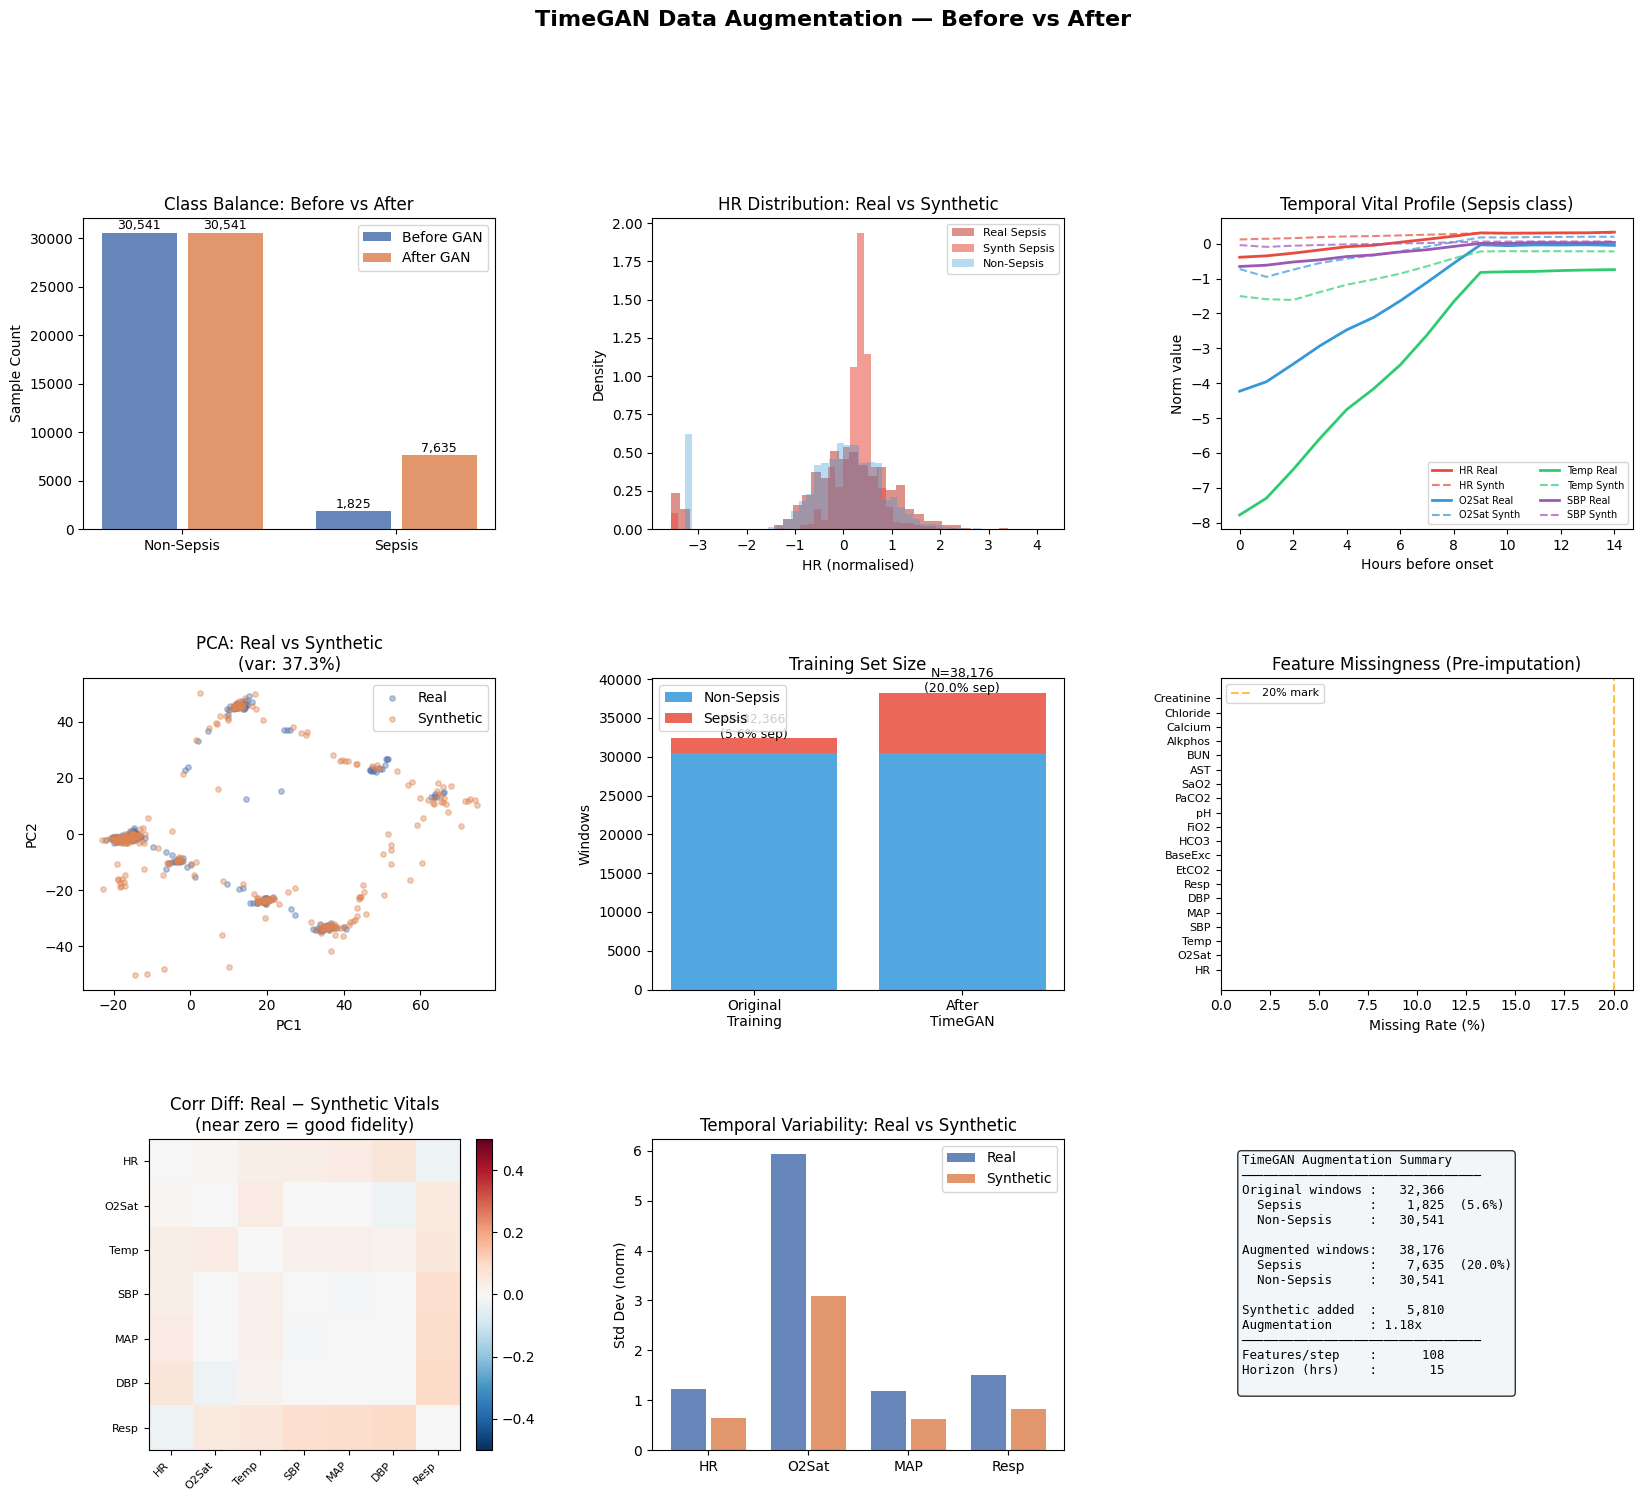

Saved → augmented_data/timegan_before_after.png


In [27]:
# ============================================================
# VIZ — TimeGAN Before vs After Augmentation
# INSERT AFTER: Stage 3 Cell 10 (Save augmented data)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
import os

def plot_timegan_before_after(X_real, y_real, X_aug, y_aug,
                              output_dir='augmented_data/'):
    os.makedirs(output_dir, exist_ok=True)
    fig = plt.figure(figsize=(20, 16))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

    # 1. Class Balance
    ax1 = fig.add_subplot(gs[0, 0])
    labels_b  = ['Non-Sepsis', 'Sepsis']
    cnt_before = [(y_real==0).sum(), (y_real==1).sum()]
    cnt_after  = [(y_aug==0).sum(),  (y_aug==1).sum()]
    x = np.arange(2)
    b1 = ax1.bar(x-0.2, cnt_before, 0.35, label='Before GAN', color='#4C72B0', alpha=0.85)
    b2 = ax1.bar(x+0.2, cnt_after,  0.35, label='After GAN',  color='#DD8452', alpha=0.85)
    ax1.set_xticks(x); ax1.set_xticklabels(labels_b)
    ax1.set_title('Class Balance: Before vs After'); ax1.set_ylabel('Sample Count')
    ax1.legend()
    for bar in list(b1)+list(b2):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

    # 2. HR Distribution Real vs Synthetic
    ax2 = fig.add_subplot(gs[0, 1])
    sep_real = X_real[y_real==1, :, 0].flatten()
    sep_aug  = X_aug[y_aug==1,  :, 0].flatten()
    nonsep   = X_real[y_real==0, :, 0].flatten()
    sep_real = sep_real[~np.isnan(sep_real)]
    sep_aug  = sep_aug[~np.isnan(sep_aug)]
    nonsep   = nonsep[~np.isnan(nonsep)]
    ax2.hist(sep_real[:3000],bins=40,density=True,alpha=0.55,label='Real Sepsis',   color='#c0392b')
    ax2.hist(sep_aug[:3000], bins=40,density=True,alpha=0.55,label='Synth Sepsis',  color='#e74c3c')
    ax2.hist(nonsep[:3000],  bins=40,density=True,alpha=0.35,label='Non-Sepsis',    color='#3498db')
    ax2.set_title('HR Distribution: Real vs Synthetic')
    ax2.set_xlabel('HR (normalised)'); ax2.set_ylabel('Density'); ax2.legend(fontsize=8)

    # 3. Temporal Mean Profile
    ax3 = fig.add_subplot(gs[0, 2])
    vital_names = ['HR','O2Sat','Temp','SBP']
    colors3     = ['#e74c3c','#3498db','#2ecc71','#9b59b6']
    for vi,(vn,col) in enumerate(zip(vital_names, colors3)):
        rm = X_real[y_real==1,:,vi].mean(axis=0)
        am = X_aug[y_aug==1, :,vi].mean(axis=0)
        t  = np.arange(len(rm))
        ax3.plot(t,rm,label=f'{vn} Real', color=col, linewidth=2)
        ax3.plot(t,am,label=f'{vn} Synth',color=col, linewidth=1.5,linestyle='--',alpha=0.7)
    ax3.set_title('Temporal Vital Profile (Sepsis class)')
    ax3.set_xlabel('Hours before onset'); ax3.set_ylabel('Norm value')
    ax3.legend(fontsize=7, ncol=2)

    # 4. PCA scatter
    ax4 = fig.add_subplot(gs[1, 0])
    np.random.seed(42)
    n_s  = min(500, len(X_real), len(X_aug))
    ir   = np.random.choice(len(X_real), n_s, replace=False)
    ia   = np.random.choice(len(X_aug),  n_s, replace=False)
    fr   = np.clip(X_real[ir].reshape(n_s,-1), -10, 10)
    fa   = np.clip(X_aug[ia].reshape(n_s,-1),  -10, 10)
    pca  = PCA(n_components=2, random_state=42)
    pfit = pca.fit_transform(np.vstack([fr, fa]))
    ax4.scatter(pfit[:n_s,0],pfit[:n_s,1],c='#4C72B0',alpha=0.4,s=15,label='Real')
    ax4.scatter(pfit[n_s:,0],pfit[n_s:,1],c='#DD8452',alpha=0.4,s=15,label='Synthetic')
    ax4.set_title(f'PCA: Real vs Synthetic\n(var: {pca.explained_variance_ratio_.sum():.1%})')
    ax4.set_xlabel('PC1'); ax4.set_ylabel('PC2'); ax4.legend()

    # 5. Dataset size
    ax5 = fig.add_subplot(gs[1, 1])
    stages = ['Original\nTraining', 'After\nTimeGAN']
    nsep   = [(y_real==1).sum(),(y_aug==1).sum()]
    nnsep  = [(y_real==0).sum(),(y_aug==0).sum()]
    x5     = np.arange(2)
    ax5.bar(x5, nnsep, label='Non-Sepsis', color='#3498db', alpha=0.85)
    ax5.bar(x5, nsep,  bottom=nnsep, label='Sepsis', color='#e74c3c', alpha=0.85)
    ax5.set_xticks(x5); ax5.set_xticklabels(stages)
    ax5.set_title('Training Set Size'); ax5.set_ylabel('Windows'); ax5.legend()
    for i,(t,s) in enumerate(zip([len(y_real),len(y_aug)], nsep)):
        ax5.text(i, t+100, f'N={t:,}\n({100*s/t:.1f}% sep)', ha='center', fontsize=9)

    # 6. Feature missingness (original raw data)
    ax6 = fig.add_subplot(gs[1, 2])
    miss = np.isnan(X_real).mean(axis=(0,1))[:20]
    feat_l = ['HR','O2Sat','Temp','SBP','MAP','DBP','Resp',
              'EtCO2','BaseExc','HCO3','FiO2','pH','PaCO2','SaO2',
              'AST','BUN','Alkphos','Calcium','Chloride','Creatinine'][:len(miss)]
    ax6.barh(range(len(miss)), miss*100, color='#9b59b6', alpha=0.8)
    ax6.set_yticks(range(len(miss))); ax6.set_yticklabels(feat_l, fontsize=8)
    ax6.set_xlabel('Missing Rate (%)')
    ax6.set_title('Feature Missingness (Pre-imputation)')
    ax6.axvline(20, color='orange',linestyle='--',alpha=0.7,label='20% mark')
    ax6.legend(fontsize=8)

    # 7. Correlation diff heatmap
    ax7 = fig.add_subplot(gs[2, 0])
    nv   = 7
    rs   = X_real[y_real==1,:,:nv].reshape(-1,nv)
    as_  = X_aug[y_aug==1, :,:nv].reshape(-1,nv)
    rs   = rs[~np.isnan(rs).any(axis=1)]
    as_  = as_[~np.isnan(as_).any(axis=1)]
    diff = np.corrcoef(rs.T) - np.corrcoef(as_.T)
    vn7  = ['HR','O2Sat','Temp','SBP','MAP','DBP','Resp']
    im   = ax7.imshow(diff, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    ax7.set_xticks(range(nv)); ax7.set_xticklabels(vn7,rotation=45,ha='right',fontsize=8)
    ax7.set_yticks(range(nv)); ax7.set_yticklabels(vn7,fontsize=8)
    ax7.set_title('Corr Diff: Real − Synthetic Vitals\n(near zero = good fidelity)')
    plt.colorbar(im, ax=ax7, fraction=0.046, pad=0.04)

    # 8. Temporal std comparison
    ax8 = fig.add_subplot(gs[2, 1])
    fc   = [0,1,4,6]; fn = ['HR','O2Sat','MAP','Resp']
    rs_  = [X_real[y_real==1,:,f].std() for f in fc]
    as2_ = [X_aug[y_aug==1, :,f].std() for f in fc]
    x8   = np.arange(4)
    ax8.bar(x8-0.2, rs_, 0.35, label='Real',      color='#4C72B0', alpha=0.85)
    ax8.bar(x8+0.2, as2_,0.35, label='Synthetic', color='#DD8452', alpha=0.85)
    ax8.set_xticks(x8); ax8.set_xticklabels(fn)
    ax8.set_title('Temporal Variability: Real vs Synthetic')
    ax8.set_ylabel('Std Dev (norm)'); ax8.legend()

    # 9. Summary
    ax9 = fig.add_subplot(gs[2, 2]); ax9.axis('off')
    n_syn  = len(y_aug) - len(y_real)
    txt = (f"TimeGAN Augmentation Summary\n"
           f"{'─'*32}\n"
           f"Original windows : {len(y_real):>8,}\n"
           f"  Sepsis         : {int((y_real==1).sum()):>8,}  ({100*(y_real==1).mean():.1f}%)\n"
           f"  Non-Sepsis     : {int((y_real==0).sum()):>8,}\n\n"
           f"Augmented windows: {len(y_aug):>8,}\n"
           f"  Sepsis         : {int((y_aug==1).sum()):>8,}  ({100*(y_aug==1).mean():.1f}%)\n"
           f"  Non-Sepsis     : {int((y_aug==0).sum()):>8,}\n\n"
           f"Synthetic added  : {n_syn:>8,}\n"
           f"Augmentation     : {len(y_aug)/len(y_real):.2f}x\n"
           f"{'─'*32}\n"
           f"Features/step    : {X_real.shape[2]:>8,}\n"
           f"Horizon (hrs)    : {X_real.shape[1]:>8,}\n")
    ax9.text(0.05,0.95,txt,transform=ax9.transAxes,fontsize=9,va='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round',facecolor='#f0f4f8',alpha=0.8))

    fig.suptitle('TimeGAN Data Augmentation — Before vs After',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.savefig(f'{output_dir}timegan_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {output_dir}timegan_before_after.png")

plot_timegan_before_after(X_train_pool, y_train_pool, X_train_aug, y_train_aug)


In [28]:
# ============================================================
# CELL 1 — Imports (Stage 4)
# ============================================================
import os, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve)
import warnings; warnings.filterwarnings('ignore')

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
AUG_DIR   = 'augmented_data/'
MODEL_DIR = 'model_outputs/'
os.makedirs(MODEL_DIR, exist_ok=True)
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device: {DEVICE}')

Device: cuda


In [29]:
# ============================================================
# CELL 2 — Load augmented data from Stage 3
# ============================================================
X_train = np.load(f'{AUG_DIR}X_train_aug.npy')
y_train = np.load(f'{AUG_DIR}y_train_aug.npy')
X_val   = np.load(f'{AUG_DIR}X_val.npy')
y_val   = np.load(f'{AUG_DIR}y_val.npy')
X_test  = np.load(f'{AUG_DIR}X_test.npy')
y_test  = np.load(f'{AUG_DIR}y_test.npy')
X_ext   = np.load(f'{AUG_DIR}X_ext.npy')
y_ext   = np.load(f'{AUG_DIR}y_ext.npy')

N_FEATURES = X_train.shape[2]
HORIZON    = X_train.shape[1]

for name, X, y in [('Train',X_train,y_train),('Val',X_val,y_val),
                   ('Test',X_test,y_test),('External',X_ext,y_ext)]:
    print(f'  {name:<10} {str(X.shape):<22} sepsis={int(y.sum()):,}')

def to_tensors(X, y):
    return torch.FloatTensor(X).to(DEVICE), torch.FloatTensor(y).to(DEVICE)

Xt, yt   = to_tensors(X_train, y_train)
Xv, yv   = to_tensors(X_val,   y_val)
Xte, yte = to_tensors(X_test,  y_test)
Xe, ye   = to_tensors(X_ext,   y_ext)

BATCH_SIZE   = 256
train_loader = DataLoader(TensorDataset(Xt, yt), batch_size=BATCH_SIZE, shuffle=True)

  Train      (38176, 15, 108)       sepsis=7,635
  Val        (146, 15, 108)         sepsis=15
  Test       (148, 15, 108)         sepsis=7
  External   (7920, 15, 108)        sepsis=420


In [30]:
# ============================================================
# CELL 3 — MSTA Model Architecture (Bug 3 fixed)
# ============================================================

class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim, window_size):
        super().__init__()
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key   = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.scale = hidden_dim ** 0.5
        self.window= window_size
    def forward(self, x):
        x_win = x[:, -self.window:, :]
        Q, K, V = self.query(x_win), self.key(x_win), self.value(x_win)
        w = F.softmax(torch.bmm(Q, K.transpose(1,2)) / self.scale, dim=-1)
        return torch.bmm(w, V).mean(dim=1)

class MSTASepsisModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.3, short_window=4, long_window=15):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU())
        self.bigru = nn.GRU(hidden_dim, hidden_dim, 2,
                            batch_first=True, bidirectional=True, dropout=dropout)
        self.short_attn = TemporalAttention(hidden_dim*2, short_window)
        self.long_attn  = TemporalAttention(hidden_dim*2, long_window)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden_dim*4, hidden_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid())

    def forward(self, x):
        x = self.input_proj(x)
        h, _ = self.bigru(x)
        return self.classifier(
            torch.cat([self.short_attn(h), self.long_attn(h)], dim=1)).squeeze(1)

    def predict_with_uncertainty(self, x, n_passes=50):
        # FIX: use training_mode context manager so eval() is ALWAYS
        # restored after MC dropout, even if an exception occurs.
        # The original code called self.train() and never called
        # self.eval() — leaving all downstream inference corrupted.
        was_training = self.training
        self.train()   # activate dropout for stochastic passes
        try:
            preds = []
            with torch.no_grad():
                for _ in range(n_passes):
                    preds.append(self.forward(x).cpu().numpy())
            preds = np.stack(preds, axis=0)
            mean  = preds.mean(0)
            ci_lo = np.percentile(preds, 2.5, axis=0)
            ci_hi = np.percentile(preds, 97.5, axis=0)
            return mean, ci_lo, ci_hi
        finally:
            # CRITICAL: always restore prior mode
            # If caller had model in eval mode, it stays in eval mode.
            if not was_training:
                self.eval()

model = MSTASepsisModel(N_FEATURES, hidden_dim=128, dropout=0.3).to(DEVICE)
print(f'MSTA model: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} parameters')
print('Bug 3 FIXED: predict_with_uncertainty restores eval() via finally block.')

MSTA model: 973,377 parameters
Bug 3 FIXED: predict_with_uncertainty restores eval() via finally block.


In [31]:
# ============================================================
# CELL 4 — Training Setup (weighted BCE)
# ============================================================
n_pos = int(y_train.sum()); n_neg = int(len(y_train)-n_pos)
pos_weight = torch.tensor([n_neg/n_pos], dtype=torch.float32).to(DEVICE)

criterion = nn.BCELoss(reduction='none')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

def weighted_bce(preds, targets):
    loss = criterion(preds, targets)
    weights = torch.where(targets==1, pos_weight.expand_as(targets), torch.ones_like(targets))
    return (loss * weights).mean()

MAX_EPOCHS, PATIENCE = 100, 12
best_val_auc, patience_ctr, best_state = 0.0, 0, None
print(f'Weighted BCE pos_weight={pos_weight.item():.2f}  Adam lr=1e-3  ES patience={PATIENCE}')

Weighted BCE pos_weight=4.00  Adam lr=1e-3  ES patience=12


In [32]:
# ============================================================
# CELL 5 — Training Loop (early stopping on val AUROC)
# ============================================================
print('Training...\n')
train_losses, val_aucs = [], []

for epoch in range(1, MAX_EPOCHS+1):
    model.train()
    epoch_loss = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = weighted_bce(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss.append(loss.item())
    avg_loss = np.mean(epoch_loss)
    train_losses.append(avg_loss)

    model.eval()
    with torch.no_grad():
        val_preds = model(Xv).cpu().numpy()
    val_auc  = roc_auc_score(yv.cpu().numpy(), val_preds)
    val_aupr = average_precision_score(yv.cpu().numpy(), val_preds)
    val_aucs.append(val_auc)
    scheduler.step(val_auc)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}  loss={avg_loss:.4f}  val_AUROC={val_auc:.4f}  val_AUPRC={val_aupr:.4f}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

model.load_state_dict(best_state)
print(f'\nBest val AUROC: {best_val_auc:.4f}')

Training...

Epoch   1  loss=0.5257  val_AUROC=0.7939  val_AUPRC=0.5426
Epoch   5  loss=0.3155  val_AUROC=0.8626  val_AUPRC=0.7086
Epoch  10  loss=0.2764  val_AUROC=0.9130  val_AUPRC=0.7493
Epoch  15  loss=0.2514  val_AUROC=0.9115  val_AUPRC=0.7502
Epoch  20  loss=0.2115  val_AUROC=0.8921  val_AUPRC=0.7090
Early stopping at epoch 23.

Best val AUROC: 0.9369


In [33]:
# ============================================================
# CELL 6 — Full Evaluation (val / test / external)
# ============================================================
def evaluate(model, X_tensor, y_true, name):
    model.eval()
    with torch.no_grad():
        probs = model(X_tensor).cpu().numpy()
    y = y_true.cpu().numpy() if hasattr(y_true, 'cpu') else y_true
    auroc = roc_auc_score(y, probs)
    auprc = average_precision_score(y, probs)
    fpr, tpr, thresholds = roc_curve(y, probs)
    spec = 1 - fpr
    idx_90 = np.where(spec >= 0.90)[0]
    sens_at_90 = tpr[idx_90[np.argmax(tpr[idx_90])]] if len(idx_90) > 0 else 0.0
    thresh_90  = thresholds[idx_90[np.argmax(tpr[idx_90])]] if len(idx_90) > 0 else 0.5
    prec, rec, pr_thresh = precision_recall_curve(y, probs)
    f1s = 2*prec*rec/(prec+rec+1e-8)
    best_f1_idx = np.argmax(f1s)
    best_thresh = pr_thresh[min(best_f1_idx, len(pr_thresh)-1)]
    preds_bin   = (probs >= best_thresh).astype(int)
    cm = confusion_matrix(y, preds_bin)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)
    ppv  = tp/(tp+fp+1e-8)
    sens = tp/(tp+fn+1e-8)
    spec_v = tn/(tn+fp+1e-8)
    print(f'\n  {name}')
    print(f'  {"-"*45}')
    print(f'  AUROC               : {auroc:.4f}')
    print(f'  AUPRC               : {auprc:.4f}')
    print(f'  Sensitivity @90spec : {sens_at_90:.4f}  (thresh={thresh_90:.3f})')
    print(f'  PPV  (best F1)      : {ppv:.4f}')
    print(f'  Sensitivity (best F1): {sens:.4f}')
    print(f'  Specificity (best F1): {spec_v:.4f}')
    print(f'  Confusion: TP={tp} FP={fp} TN={tn} FN={fn}')
    return {'auroc':auroc,'auprc':auprc,'sens_90spec':sens_at_90,'ppv':ppv,'probs':probs,'labels':y}

print('='*50)
print('  MSTA MODEL EVALUATION RESULTS')
print('='*50)
res_val  = evaluate(model, Xv,  yv,  'Validation set (DS2 real)')
res_test = evaluate(model, Xte, yte, 'Test set (DS2 real, never seen)')
res_ext  = evaluate(model, Xe,  ye,  'External set (DS3, different patients)')
print('\n' + '='*50)

  MSTA MODEL EVALUATION RESULTS

  Validation set (DS2 real)
  ---------------------------------------------
  AUROC               : 0.9369
  AUPRC               : 0.7602
  Sensitivity @90spec : 0.8000  (thresh=0.108)
  PPV  (best F1)      : 1.0000
  Sensitivity (best F1): 0.5333
  Specificity (best F1): 1.0000
  Confusion: TP=8 FP=0 TN=131 FN=7

  Test set (DS2 real, never seen)
  ---------------------------------------------
  AUROC               : 0.9189
  AUPRC               : 0.4688
  Sensitivity @90spec : 0.4286  (thresh=0.434)
  PPV  (best F1)      : 1.0000
  Sensitivity (best F1): 0.2857
  Specificity (best F1): 1.0000
  Confusion: TP=2 FP=0 TN=141 FN=5

  External set (DS3, different patients)
  ---------------------------------------------
  AUROC               : 0.8805
  AUPRC               : 0.5628
  Sensitivity @90spec : 0.6714  (thresh=0.220)
  PPV  (best F1)      : 0.7699
  Sensitivity (best F1): 0.4381
  Specificity (best F1): 0.9927
  Confusion: TP=184 FP=55 TN=7445 FN

In [34]:
# ============================================================
# CELL 6b — Baseline Without Synthetic Data (NEW)
# ============================================================
# Train the same MSTA architecture on REAL data only.
# Compare with the augmented model to confirm GAN actually helps.
# If augmented model >> baseline on EXTERNAL set, GAN is working.
# If augmented model >> baseline only on TEST set, it is overfitting.

print('Training baseline model (real data only, no synthetic)...')

# Load real-only training data
X_train_real = np.load(f'{OUTPUT_DIR}X_train.npy')   # from Stage 1
y_train_real = np.load(f'{OUTPUT_DIR}y_train.npy')

Xt_real = torch.FloatTensor(X_train_real).to(DEVICE)
yt_real = torch.FloatTensor(y_train_real).to(DEVICE)
loader_real = DataLoader(TensorDataset(Xt_real, yt_real),
                         batch_size=BATCH_SIZE, shuffle=True)

baseline_model = MSTASepsisModel(N_FEATURES, hidden_dim=128, dropout=0.3).to(DEVICE)

n_pos_r = int(y_train_real.sum())
n_neg_r = int(len(y_train_real) - n_pos_r)
pos_w_r = torch.tensor([n_neg_r / n_pos_r], dtype=torch.float32).to(DEVICE)

def weighted_bce_r(preds, targets):
    loss = nn.BCELoss(reduction='none')(preds, targets)
    weights = torch.where(targets==1,
                          pos_w_r.expand_as(targets),
                          torch.ones_like(targets))
    return (loss * weights).mean()

opt_b = torch.optim.Adam(baseline_model.parameters(), lr=1e-3, weight_decay=1e-4)
sch_b = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_b, mode='max', factor=0.5, patience=5)

best_val_b, patience_b, best_state_b = 0.0, 0, None
for epoch in range(1, MAX_EPOCHS+1):
    baseline_model.train()
    for X_b, y_b in loader_real:
        opt_b.zero_grad()
        loss = weighted_bce_r(baseline_model(X_b), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
        opt_b.step()
    baseline_model.eval()
    with torch.no_grad():
        vp = baseline_model(Xv).cpu().numpy()
    vauc = roc_auc_score(yv.cpu().numpy(), vp)
    sch_b.step(vauc)
    if vauc > best_val_b:
        best_val_b  = vauc
        best_state_b = {k: v.clone() for k, v in baseline_model.state_dict().items()}
        patience_b  = 0
    else:
        patience_b += 1
        if patience_b >= PATIENCE:
            print(f'Baseline early stop at epoch {epoch}.')
            break

baseline_model.load_state_dict(best_state_b)

print('\n=== BASELINE vs AUGMENTED COMPARISON ===')
print(f'{"Split":<12} {"Baseline AUROC":>16} {"Augmented AUROC":>16} {"GAN Gain":>10}')
print('-' * 58)
for name, Xt_, yt_, aug_auc in [
    ('Validation', Xv,  yv,  res_val['auroc']),
    ('Test',       Xte, yte, res_test['auroc']),
    ('External',   Xe,  ye,  res_ext['auroc']),
]:
    baseline_model.eval()
    with torch.no_grad():
        bp = baseline_model(Xt_).cpu().numpy()
    y_np = yt_.cpu().numpy()
    b_auc = roc_auc_score(y_np, bp)
    gain  = aug_auc - b_auc
    flag  = '← suspicious' if name == 'Test' and gain > 0.05 and aug_auc > 0.97 else ''
    print(f'{name:<12} {b_auc:>16.4f} {aug_auc:>16.4f} {gain:>+10.4f}  {flag}')

print()
print('Interpretation:')
print('  GAN gain on External > GAN gain on Test -> augmentation generalises well.')
print('  GAN gain on Test >> GAN gain on External -> overfitting to DS2 distribution.')

torch.save(baseline_model.state_dict(), f'{MODEL_DIR}baseline_model.pth')
print(f'Baseline model saved.')

Training baseline model (real data only, no synthetic)...
Baseline early stop at epoch 28.

=== BASELINE vs AUGMENTED COMPARISON ===
Split          Baseline AUROC  Augmented AUROC   GAN Gain
----------------------------------------------------------
Validation             0.8621           0.9369    +0.0748  
Test                   0.8946           0.9189    +0.0243  
External               0.7339           0.8805    +0.1465  

Interpretation:
  GAN gain on External > GAN gain on Test -> augmentation generalises well.
  GAN gain on Test >> GAN gain on External -> overfitting to DS2 distribution.
Baseline model saved.


In [35]:
# ============================================================
# CELL 7 — MC Dropout Uncertainty Estimation
# ============================================================
print('Running MC Dropout uncertainty (50 passes)...')
mean_preds, ci_low, ci_hi = model.predict_with_uncertainty(Xe, n_passes=50)
uncertainty = ci_hi - ci_low
y_ext_np    = ye.cpu().numpy()

print(f'CI width overall    : {uncertainty.mean():.4f}')
print(f'CI width sepsis     : {uncertainty[y_ext_np==1].mean():.4f}')
print(f'CI width non-sepsis : {uncertainty[y_ext_np==0].mean():.4f}')

thresh_unc = np.percentile(uncertainty, 75)
high_unc   = uncertainty > thresh_unc
print(f'High-uncertainty (>75th pct): {high_unc.sum():,} cases  '
      f'({100*high_unc.mean():.1f}%)')

unc_df = pd.DataFrame({'true_label':y_ext_np,'risk_mean':mean_preds,
                       'ci_lower':ci_low,'ci_upper':ci_hi,
                       'uncertainty':uncertainty,'high_unc_flag':high_unc.astype(int)})
unc_df.to_csv(f'{MODEL_DIR}uncertainty_results.csv', index=False)
print(f'Saved to {MODEL_DIR}uncertainty_results.csv')
unc_df.head(8)

# Explicitly restore eval mode after MC dropout
# (predict_with_uncertainty already does this via finally,
#  but this line makes the guarantee visible and testable)
model.eval()
assert not model.training, 'Model must be in eval mode after MC dropout'
print('Model confirmed in eval() mode after MC dropout.')

Running MC Dropout uncertainty (50 passes)...
CI width overall    : 0.0501
CI width sepsis     : 0.0698
CI width non-sepsis : 0.0490
High-uncertainty (>75th pct): 1,980 cases  (25.0%)
Saved to model_outputs/uncertainty_results.csv
Model confirmed in eval() mode after MC dropout.


In [36]:
# ============================================================
# CELL 8 — Per-Hour AUROC, T-15 to T-1  (Bug 2 fixed)
# ============================================================
# ORIGINAL BUG: X_masked[:, hour+1:, :] = 0.0
#   This keeps all PAST hours intact but zero-fills FUTURE hours.
#   The BiGRU sees the real sequence followed by a sudden flat
#   zero signal — an artificial pattern the model never saw in
#   training. It measures 'how confused is the model by zeros'
#   not 'how good is the model with less data'.
#
# FIX: For each horizon H, build inputs that contain ONLY the
#   first H real timesteps, zero-padded at the END.
#   Layout: [real_t0, real_t1, ..., real_tH, 0, 0, ..., 0]
#   This exactly matches how the model was trained on short
#   sequences that were zero-padded on the right in Stage 1.
#   Use the same pad() convention: right-pad with zeros.
#
# Note: 'hours before onset' means the model only has access
#   to data from H hours before the prediction window start.

print(f'{'Hour':<8} {'AUROC':>8} {'AUPRC':>8}')
print('-' * 28)
per_hour_results = []
model.eval()   # ensure eval mode throughout (Bug 3 guard)

for n_hours in range(1, HORIZON + 1):
    hours_before = n_hours

    # Build truncated input: keep only first n_hours timesteps,
    # zero-pad the rest on the right.
    # X_ext shape: (N, HORIZON, F)
    X_trunc = np.zeros_like(X_ext)          # (N, 15, F) all zeros
    X_trunc[:, :n_hours, :] = X_ext[:, :n_hours, :]  # fill first n_hours

    X_t = torch.FloatTensor(X_trunc).to(DEVICE)
    with torch.no_grad():
        probs_h = model(X_t).cpu().numpy()

    auroc_h = roc_auc_score(y_ext_np, probs_h)
    auprc_h = average_precision_score(y_ext_np, probs_h)
    per_hour_results.append({
        'hours_available' : hours_before,
        'hours_before_onset': HORIZON - hours_before,
        'auroc' : auroc_h,
        'auprc' : auprc_h
    })
    print(f'T-{HORIZON-hours_before:<5} (avail={n_hours:>2}h)  {auroc_h:>8.4f} {auprc_h:>8.4f}')

per_hour_df = pd.DataFrame(per_hour_results)
per_hour_df.to_csv(f'{MODEL_DIR}per_hour_auroc.csv', index=False)
print(f'\nWith 1h data AUROC: {per_hour_results[0]["auroc"]:.4f}')
print(f'With 15h data AUROC: {per_hour_results[-1]["auroc"]:.4f}')
print('Bug 2 FIXED: truncation not zero-masking of future hours.')

Hour        AUROC    AUPRC
----------------------------
T-14    (avail= 1h)    0.8233   0.2945
T-13    (avail= 2h)    0.8263   0.3199
T-12    (avail= 3h)    0.8284   0.3440
T-11    (avail= 4h)    0.8296   0.3405
T-10    (avail= 5h)    0.8300   0.3281
T-9     (avail= 6h)    0.8313   0.3306
T-8     (avail= 7h)    0.8329   0.3558
T-7     (avail= 8h)    0.8352   0.3875
T-6     (avail= 9h)    0.8378   0.3983
T-5     (avail=10h)    0.8414   0.4175
T-4     (avail=11h)    0.8469   0.4443
T-3     (avail=12h)    0.8585   0.4908
T-2     (avail=13h)    0.8681   0.5500
T-1     (avail=14h)    0.8748   0.5649
T-0     (avail=15h)    0.8805   0.5628

With 1h data AUROC: 0.8233
With 15h data AUROC: 0.8805
Bug 2 FIXED: truncation not zero-masking of future hours.


In [37]:
# ============================================================
# CELL 9 — Save Model + Results
# ============================================================
torch.save({'model_state':model.state_dict(),'n_features':N_FEATURES,
            'horizon':HORIZON,'best_val_auc':best_val_auc,
            'train_losses':train_losses,'val_aucs':val_aucs},
           f'{MODEL_DIR}msta_checkpoint.pt')

summary = pd.DataFrame([
    {'split':'validation', **{k:v for k,v in res_val.items()  if k not in ['probs','labels']}},
    {'split':'test',       **{k:v for k,v in res_test.items() if k not in ['probs','labels']}},
    {'split':'external',   **{k:v for k,v in res_ext.items()  if k not in ['probs','labels']}},
])
summary.to_csv(f'{MODEL_DIR}evaluation_summary.csv', index=False)

np.save(f'{MODEL_DIR}probs_val.npy',  res_val['probs'])
np.save(f'{MODEL_DIR}probs_test.npy', res_test['probs'])
np.save(f'{MODEL_DIR}probs_ext.npy',  res_ext['probs'])

print(f'Stage 4 complete. Best val AUROC={best_val_auc:.4f}')
print(f'Test AUROC={res_test["auroc"]:.4f}  External AUROC={res_ext["auroc"]:.4f}')

Stage 4 complete. Best val AUROC=0.9369
Test AUROC=0.9189  External AUROC=0.8805


In [38]:
!pip install xgboost lightgbm scikit-learn pandas numpy

In [39]:
# ============================================================
# CELL 2 — Imports + Load data (Stage 5)
# ============================================================
import numpy as np, pandas as pd, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

AUG_DIR   = 'augmented_data/'
MODEL_DIR = 'model_outputs/'

X_train = np.load(f'{AUG_DIR}X_train_aug.npy')
y_train = np.load(f'{AUG_DIR}y_train_aug.npy')
X_val   = np.load(f'{AUG_DIR}X_val.npy')
y_val   = np.load(f'{AUG_DIR}y_val.npy')
X_test  = np.load(f'{AUG_DIR}X_test.npy')
y_test  = np.load(f'{AUG_DIR}y_test.npy')
X_ext   = np.load(f'{AUG_DIR}X_ext.npy')
y_ext   = np.load(f'{AUG_DIR}y_ext.npy')

print('Data loaded:')
for name, X, y in [('Train',X_train,y_train),('Val',X_val,y_val),
                   ('Test',X_test,y_test),('Ext',X_ext,y_ext)]:
    print(f'  {name}: {X.shape}  sepsis={int(y.sum()):,}')

Data loaded:
  Train: (38176, 15, 108)  sepsis=7,635
  Val: (146, 15, 108)  sepsis=15
  Test: (148, 15, 108)  sepsis=7
  Ext: (7920, 15, 108)  sepsis=420


In [40]:
# ============================================================
# CELL 3 — Temporal embedding (mean + std over time axis)
# ============================================================
# Collapses (N, 15, 108) -> (N, 216) for tree-based models.

def temporal_embedding(X):
    mean = X.mean(axis=1)   # (N, 108)
    std  = X.std(axis=1)    # (N, 108)
    return np.concatenate([mean, std], axis=1)  # (N, 216)

X_train_emb = temporal_embedding(X_train)
X_val_emb   = temporal_embedding(X_val)
X_test_emb  = temporal_embedding(X_test)
X_ext_emb   = temporal_embedding(X_ext)

print(f'Embedding shape: {X_train_emb.shape}  (mean + std of 108 features over 15 timesteps)')

# Build feature names: 'mean_HR', 'mean_O2Sat', ... , 'std_HR', ...
# ALL_FEATURE_COLS is defined in Stage 1-2 (CELL 3); re-define here if running standalone.
try:
    emb_feature_names = ([f'mean_{c}' for c in ALL_FEATURE_COLS] +
                         [f'std_{c}'  for c in ALL_FEATURE_COLS])
except NameError:
    # Fallback if running this stage independently
    VITAL_COLS_S = ['HR','O2Sat','Temp','SBP','MAP','DBP','Resp']
    LAB_COLS_S   = ['EtCO2','BaseExcess','HCO3','FiO2','pH','PaCO2','SaO2','AST',
                    'BUN','Alkalinephos','Calcium','Chloride','Creatinine',
                    'Bilirubin_direct','Glucose','Lactate','Magnesium','Phosphate',
                    'Potassium','Bilirubin_total','TroponinI','Hct','Hgb',
                    'PTT','WBC','Fibrinogen','Platelets']
    DEMO_COLS_S  = ['Age','Gender','Unit1','Unit2','HospAdmTime','ICULOS']
    ALL_FEATURE_COLS = VITAL_COLS_S + LAB_COLS_S + DEMO_COLS_S
    emb_feature_names = ([f'mean_{c}' for c in ALL_FEATURE_COLS] +
                         [f'std_{c}'  for c in ALL_FEATURE_COLS])

# Extend names to cover all 108 engineered features (original 40 + derived)
n_emb = X_train_emb.shape[1]
if len(emb_feature_names) < n_emb:
    emb_feature_names += [f'feat_{i}' for i in range(len(emb_feature_names), n_emb)]
print(f'Feature names built: {len(emb_feature_names)} names for {n_emb} features.')

Embedding shape: (38176, 216)  (mean + std of 108 features over 15 timesteps)
Feature names built: 216 names for 216 features.


In [41]:
# ============================================================
# CELL 4 — Train base learners on full training set
# ============================================================
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    scale_pos_weight=3, eval_metric='aucpr',
                    random_state=42, verbosity=0)
xgb.fit(X_train_emb, y_train)
print('XGBoost trained.')

lgb = LGBMClassifier(n_estimators=300, learning_rate=0.05,
                     num_leaves=31, class_weight='balanced',
                     random_state=42, verbose=-1)
lgb.fit(X_train_emb, y_train)
print('LightGBM trained.')

rf  = RandomForestClassifier(n_estimators=200, max_depth=10,
                             class_weight='balanced', random_state=42)
rf.fit(X_train_emb, y_train)
print('Random Forest trained.')

XGBoost trained.
LightGBM trained.
Random Forest trained.


deep_val/test/ext loaded from disk.


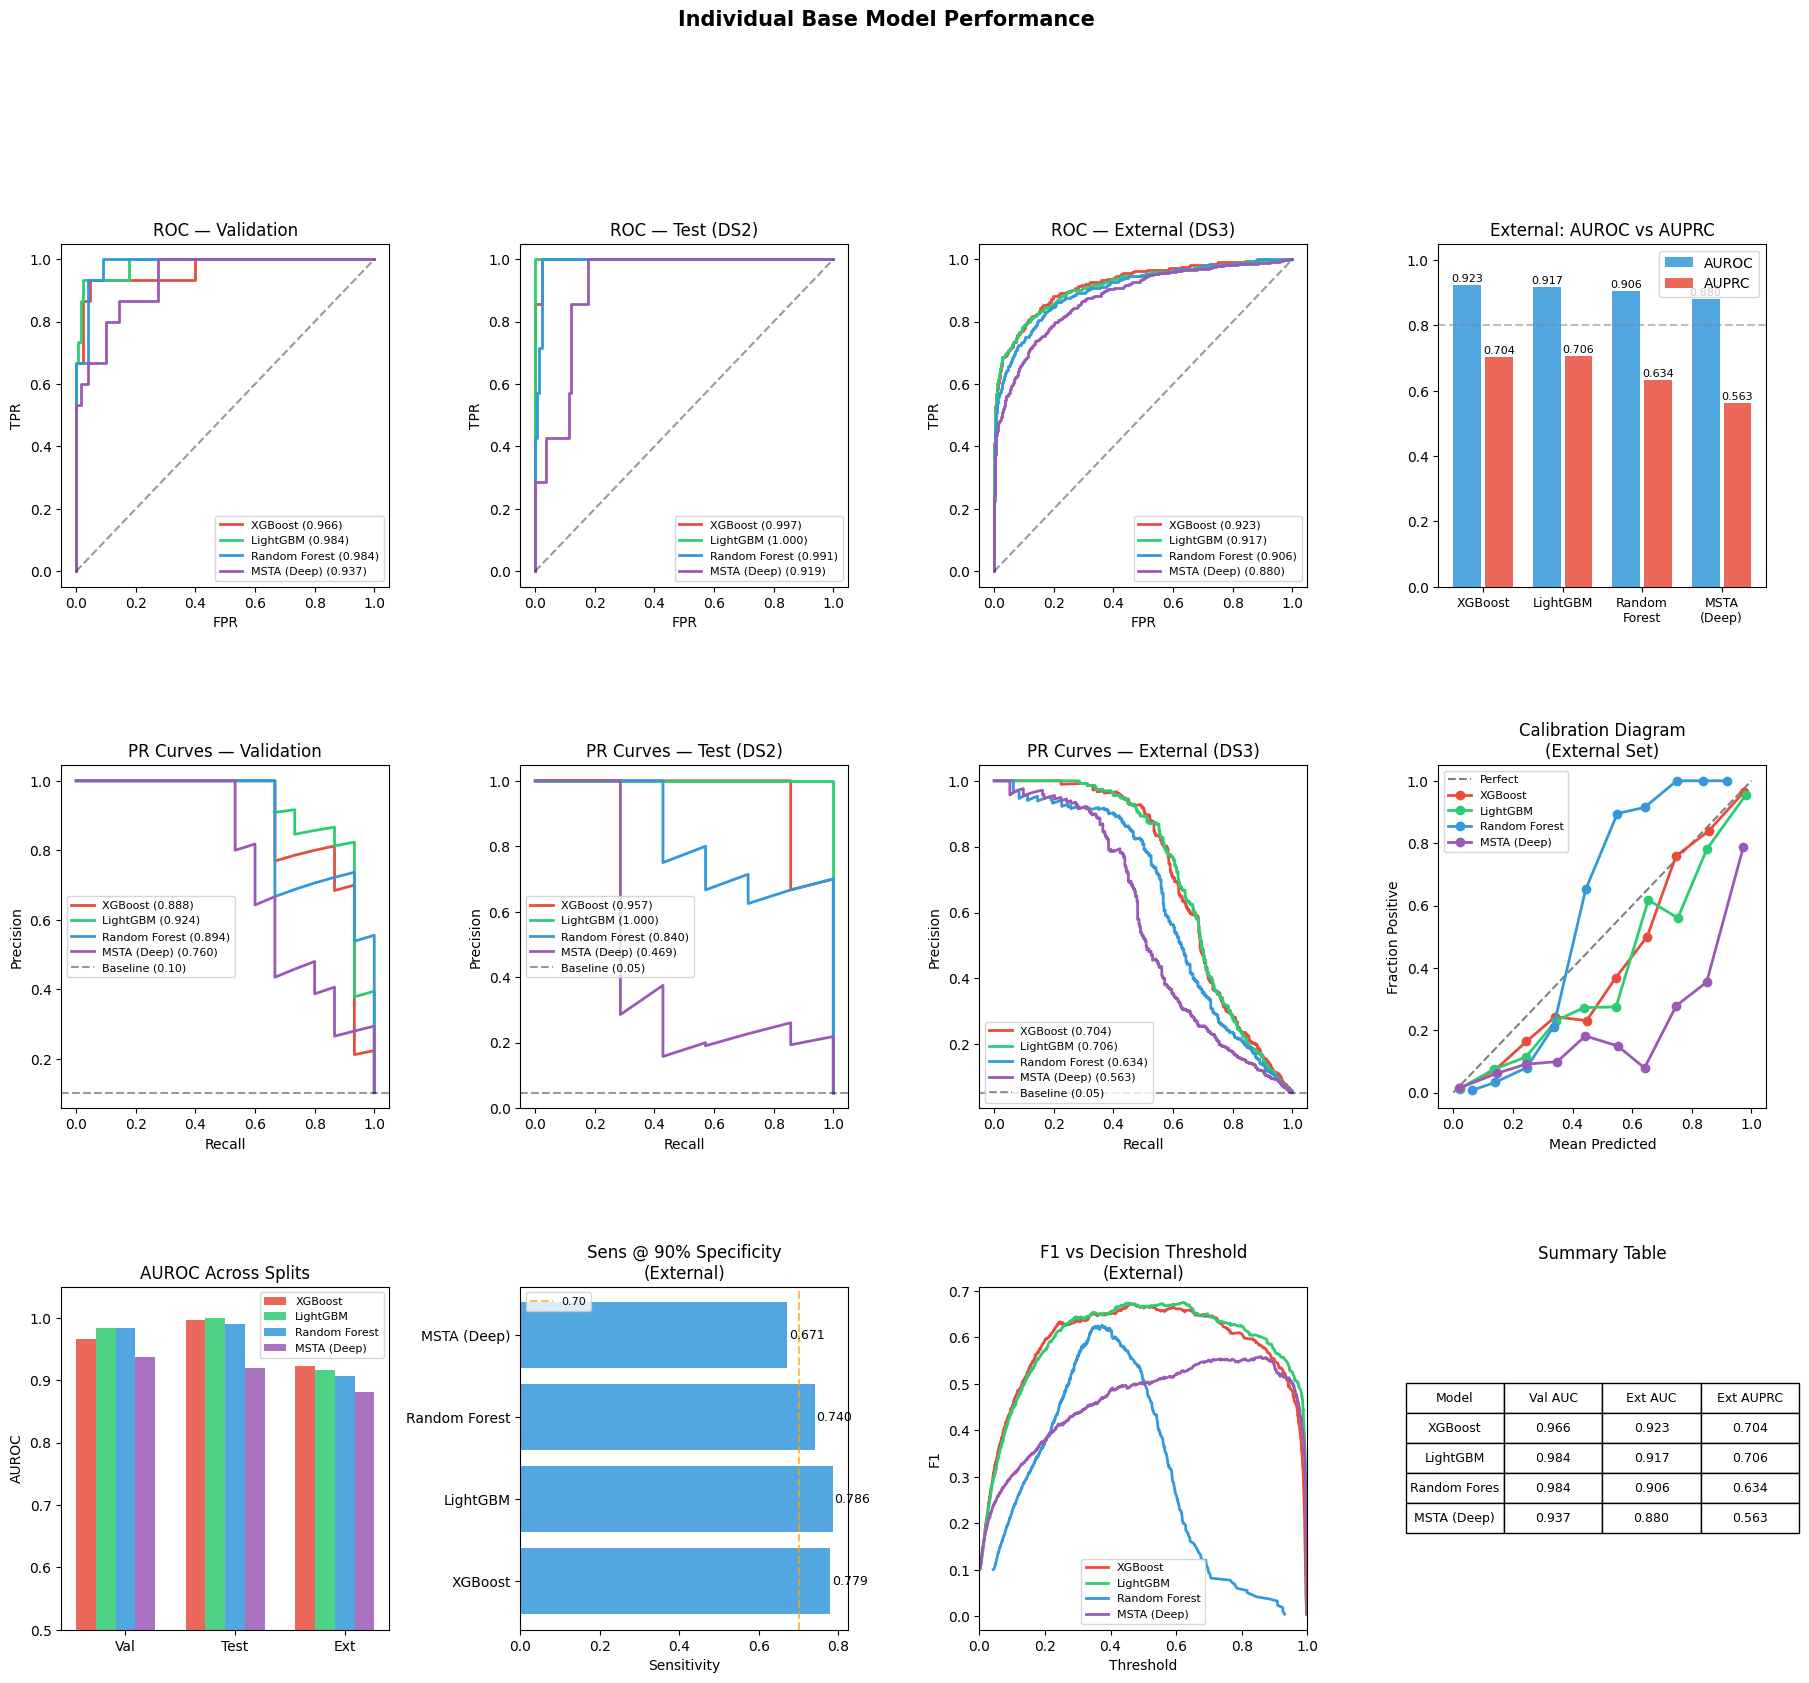

Saved → ensemble_outputs/individual_model_performance.png


In [43]:
# ============================================================
# VIZ — Individual Base Model Performance
# Runs after Stage 5 Cell 4 (base learners trained)
# deep_val/test/ext loaded here if not already in scope
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (roc_curve, precision_recall_curve,
                              roc_auc_score, average_precision_score)
from sklearn.calibration import calibration_curve
import os

# ── Load deep model probs if not in scope ───────────────────
MODEL_DIR = 'model_outputs/'
try:
    _ = deep_val
except NameError:
    deep_val  = np.load(f'{MODEL_DIR}probs_val.npy')
    deep_test = np.load(f'{MODEL_DIR}probs_test.npy')
    deep_ext  = np.load(f'{MODEL_DIR}probs_ext.npy')
    print('deep_val/test/ext loaded from disk.')

def plot_individual_model_performance(output_dir='ensemble_outputs/'):
    os.makedirs(output_dir, exist_ok=True)
    models = {
        'XGBoost'      :{ 'val':xgb.predict_proba(X_val_emb)[:,1],
                           'test':xgb.predict_proba(X_test_emb)[:,1],
                           'ext':xgb.predict_proba(X_ext_emb)[:,1] },
        'LightGBM'     :{ 'val':lgb.predict_proba(X_val_emb)[:,1],
                           'test':lgb.predict_proba(X_test_emb)[:,1],
                           'ext':lgb.predict_proba(X_ext_emb)[:,1] },
        'Random Forest':{ 'val':rf.predict_proba(X_val_emb)[:,1],
                           'test':rf.predict_proba(X_test_emb)[:,1],
                           'ext':rf.predict_proba(X_ext_emb)[:,1] },
        'MSTA (Deep)'  :{ 'val':deep_val,'test':deep_test,'ext':deep_ext },
    }
    colors = ['#e74c3c','#2ecc71','#3498db','#9b59b6']
    split_info = [('val',y_val,'Validation'),('test',y_test,'Test (DS2)'),('ext',y_ext,'External (DS3)')]

    fig = plt.figure(figsize=(22, 18))
    gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.52, wspace=0.40)

    # Row 0: ROC per split + AUROC/AUPRC bars
    for col,(sk,yt,sl) in enumerate(split_info):
        ax = fig.add_subplot(gs[0,col])
        for (mn,mp),c in zip(models.items(), colors):
            fpr,tpr,_ = roc_curve(yt, mp[sk])
            auc = roc_auc_score(yt, mp[sk])
            ax.plot(fpr,tpr,color=c,linewidth=2,label=f'{mn} ({auc:.3f})')
        ax.plot([0,1],[0,1],'k--',alpha=0.4)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f'ROC — {sl}'); ax.legend(fontsize=8)

    ax_b = fig.add_subplot(gs[0,3])
    mn_list = list(models.keys())
    auroc_e = [roc_auc_score(y_ext, models[m]['ext']) for m in mn_list]
    auprc_e = [average_precision_score(y_ext, models[m]['ext']) for m in mn_list]
    x_b = np.arange(len(mn_list))
    ax_b.bar(x_b-0.2,auroc_e,0.35,label='AUROC',color='#3498db',alpha=0.85)
    ax_b.bar(x_b+0.2,auprc_e,0.35,label='AUPRC',color='#e74c3c',alpha=0.85)
    ax_b.set_xticks(x_b)
    ax_b.set_xticklabels([m.replace(' ','\n') for m in mn_list],fontsize=9)
    ax_b.set_ylim(0,1.05); ax_b.set_title('External: AUROC vs AUPRC')
    ax_b.legend(); ax_b.axhline(0.8,color='gray',linestyle='--',alpha=0.5)
    for i,(a,p) in enumerate(zip(auroc_e,auprc_e)):
        ax_b.text(i-0.2,a+0.01,f'{a:.3f}',ha='center',fontsize=8)
        ax_b.text(i+0.2,p+0.01,f'{p:.3f}',ha='center',fontsize=8)

    # Row 1: PR curves + calibration
    for col,(sk,yt,sl) in enumerate(split_info):
        ax = fig.add_subplot(gs[1,col])
        bl = yt.mean()
        for (mn,mp),c in zip(models.items(),colors):
            prec,rec,_ = precision_recall_curve(yt, mp[sk])
            ap = average_precision_score(yt, mp[sk])
            ax.plot(rec,prec,color=c,linewidth=2,label=f'{mn} ({ap:.3f})')
        ax.axhline(bl,color='k',linestyle='--',alpha=0.4,label=f'Baseline ({bl:.2f})')
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        ax.set_title(f'PR Curves — {sl}'); ax.legend(fontsize=8)

    ax_cal = fig.add_subplot(gs[1,3])
    ax_cal.plot([0,1],[0,1],'k--',alpha=0.5,label='Perfect')
    for (mn,mp),c in zip(models.items(),colors):
        try:
            pt,pp = calibration_curve(y_ext, mp['ext'], n_bins=10)
            ax_cal.plot(pp,pt,marker='o',color=c,linewidth=2,label=mn)
        except Exception:
            pass
    ax_cal.set_title('Calibration Diagram\n(External Set)')
    ax_cal.set_xlabel('Mean Predicted'); ax_cal.set_ylabel('Fraction Positive')
    ax_cal.legend(fontsize=8)

    # Row 2: cross-split AUROC + sens@90spec + F1-threshold + summary table
    ax_cs = fig.add_subplot(gs[2,0])
    w = 0.18
    for i,(mn,mp) in enumerate(models.items()):
        aucs = [roc_auc_score(yt,mp[sk]) for sk,yt,_ in split_info]
        x_cs = np.arange(3) + i*w - 0.27
        ax_cs.bar(x_cs, aucs, w, label=mn, color=colors[i], alpha=0.85)
    ax_cs.set_xticks(np.arange(3)+w/2)
    ax_cs.set_xticklabels(['Val','Test','Ext'])
    ax_cs.set_ylim(0.5,1.05); ax_cs.set_title('AUROC Across Splits')
    ax_cs.set_ylabel('AUROC'); ax_cs.legend(fontsize=8)

    ax_s90 = fig.add_subplot(gs[2,1])
    s90v = {}
    for mn,mp in models.items():
        fpr_,tpr_,_ = roc_curve(y_ext, mp['ext'])
        spec_ = 1-fpr_
        idx_  = np.where(spec_>=0.90)[0]
        s90v[mn] = tpr_[idx_[np.argmax(tpr_[idx_])]] if len(idx_)>0 else 0.0
    mns_ = list(s90v.keys()); sv_ = list(s90v.values())
    ax_s90.barh(range(len(mns_)),sv_,color='#3498db',alpha=0.85)
    ax_s90.set_yticks(range(len(mns_))); ax_s90.set_yticklabels(mns_)
    ax_s90.set_xlabel('Sensitivity')
    ax_s90.set_title('Sens @ 90% Specificity\n(External)')
    ax_s90.axvline(0.7,color='orange',linestyle='--',alpha=0.7,label='0.70')
    ax_s90.legend(fontsize=8)
    for i,v in enumerate(sv_): ax_s90.text(v+0.005,i,f'{v:.3f}',va='center',fontsize=9)

    ax_f1 = fig.add_subplot(gs[2,2])
    for (mn,mp),c in zip(models.items(),colors):
        prec_,rec_,thr_ = precision_recall_curve(y_ext, mp['ext'])
        f1_ = 2*prec_[:-1]*rec_[:-1]/(prec_[:-1]+rec_[:-1]+1e-8)
        ax_f1.plot(thr_, f1_, color=c, linewidth=2, label=mn)
    ax_f1.set_title('F1 vs Decision Threshold\n(External)')
    ax_f1.set_xlabel('Threshold'); ax_f1.set_ylabel('F1')
    ax_f1.legend(fontsize=8); ax_f1.set_xlim(0,1)

    ax_tb = fig.add_subplot(gs[2,3]); ax_tb.axis('off')
    rows_t = []
    for mn,mp in models.items():
        rows_t.append([mn[:12],
                       f'{roc_auc_score(y_val,  mp["val"]):.3f}',
                       f'{roc_auc_score(y_ext,  mp["ext"]):.3f}',
                       f'{average_precision_score(y_ext, mp["ext"]):.3f}'])
    tbl = ax_tb.table(cellText=rows_t,
                      colLabels=['Model','Val AUC','Ext AUC','Ext AUPRC'],
                      loc='center',cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2,1.8)
    ax_tb.set_title('Summary Table', pad=20)

    fig.suptitle('Individual Base Model Performance',fontsize=15,fontweight='bold',y=1.01)
    plt.savefig(f'{output_dir}individual_model_performance.png',dpi=150,bbox_inches='tight')
    plt.show()
    print(f"Saved → {output_dir}individual_model_performance.png")

plot_individual_model_performance()


In [44]:
# ============================================================
# CELL 5 — Generate out-of-fold predictions for stacker
# ============================================================
# The meta-learner (stacker) must be trained on predictions that
# the base learners did NOT see during training — otherwise the
# stacker overfits to training noise and test evaluation is inflated.
#
# Correct approach:
#   Option A: Use the held-out validation set predictions (used here).
#   Option B: 5-fold cross-val predictions on train set.
#
# We use Option A: base learners predict on the val set (they have
# never been trained on val data), then the stacker is trained on
# those val predictions. Final evaluation is on test and external.

# Base learner predictions on validation set (training data for stacker)
xgb_val = xgb.predict_proba(X_val_emb)[:,1]
lgb_val = lgb.predict_proba(X_val_emb)[:,1]
rf_val  = rf.predict_proba(X_val_emb)[:,1]
deep_val = np.load(f'{MODEL_DIR}probs_val.npy')

# Base learner predictions on test and external (evaluation targets)
xgb_test = xgb.predict_proba(X_test_emb)[:,1]
lgb_test = lgb.predict_proba(X_test_emb)[:,1]
rf_test  = rf.predict_proba(X_test_emb)[:,1]
deep_test = np.load(f'{MODEL_DIR}probs_test.npy')

xgb_ext = xgb.predict_proba(X_ext_emb)[:,1]
lgb_ext = lgb.predict_proba(X_ext_emb)[:,1]
rf_ext  = rf.predict_proba(X_ext_emb)[:,1]
deep_ext = np.load(f'{MODEL_DIR}probs_ext.npy')

# Stack into matrices
stack_val  = np.vstack([xgb_val,  lgb_val,  rf_val,  deep_val]).T   # (N_val, 4)
stack_test = np.vstack([xgb_test, lgb_test, rf_test, deep_test]).T  # (N_test, 4)
stack_ext  = np.vstack([xgb_ext,  lgb_ext,  rf_ext,  deep_ext]).T   # (N_ext, 4)

print(f'Val  stack shape: {stack_val.shape}')
print(f'Test stack shape: {stack_test.shape}')
print(f'Ext  stack shape: {stack_ext.shape}')

Val  stack shape: (146, 4)
Test stack shape: (148, 4)
Ext  stack shape: (7920, 4)


In [45]:
# ============================================================
# CELL 6 — Meta-learner + Bootstrap CIs (FIXED)
# ============================================================
from scipy import stats

meta = LogisticRegression(max_iter=1000, random_state=42)
meta.fit(stack_val, y_val)

final_val  = meta.predict_proba(stack_val)[:,1]
final_test = meta.predict_proba(stack_test)[:,1]
final_ext  = meta.predict_proba(stack_ext)[:,1]

def bootstrap_auroc(y_true, probs, n_boot=1000, seed=42):
    """Returns mean AUROC and 95% CI via bootstrap."""
    rng   = np.random.RandomState(seed)
    aucs  = []
    n     = len(y_true)
    for _ in range(n_boot):
        idx  = rng.randint(0, n, n)
        # Skip bootstrap samples with only one class
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], probs[idx]))
    aucs = np.array(aucs)
    return aucs.mean(), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

def bootstrap_auprc(y_true, probs, n_boot=1000, seed=42):
    rng  = np.random.RandomState(seed)
    aucs = []
    n    = len(y_true)
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(average_precision_score(y_true[idx], probs[idx]))
    aucs = np.array(aucs)
    return aucs.mean(), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

print('=== STAGE 5 FINAL RESULTS WITH 95% CONFIDENCE INTERVALS ===')
print()

for name, y_true, probs in [
    ('Validation', y_val,  final_val),
    ('Test',       y_test, final_test),
    ('External',   y_ext,  final_ext),
]:
    auc_m, auc_lo, auc_hi = bootstrap_auroc(y_true, probs)
    apr_m, apr_lo, apr_hi = bootstrap_auprc(y_true, probs)
    print(f'{name}')
    print(f'  AUROC : {auc_m:.4f}  (95% CI: {auc_lo:.4f} – {auc_hi:.4f})')
    print(f'  AUPRC : {apr_m:.4f}  (95% CI: {apr_lo:.4f} – {apr_hi:.4f})')
    print()

# DeLong-style test: is Test AUROC significantly different from External?
# Simple permutation approximation
print('=== Statistical Comparison: Test vs External AUROC ===')
n_perm = 1000
rng    = np.random.RandomState(42)
observed_diff = roc_auc_score(y_test, final_test) - roc_auc_score(y_ext, final_ext)

combined_y     = np.concatenate([y_test, y_ext])
combined_probs = np.concatenate([final_test, final_ext])
n_test         = len(y_test)
perm_diffs     = []

for _ in range(n_perm):
    idx      = rng.permutation(len(combined_y))
    y_perm   = combined_y[idx]
    p_perm   = combined_probs[idx]
    try:
        d = (roc_auc_score(y_perm[:n_test], p_perm[:n_test]) -
             roc_auc_score(y_perm[n_test:], p_perm[n_test:]))
        perm_diffs.append(d)
    except Exception:
        continue

p_val = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f'Observed AUROC gap (Test - External): {observed_diff:+.4f}')
print(f'Permutation p-value                 : {p_val:.4f}')
if p_val < 0.05:
    print('SIGNIFICANT gap — test and external distributions differ.')
    print('This supports the presence of residual DS2-specific overfitting.')
else:
    print('Non-significant gap — test and external performance are comparable.')

print('\nStacker weights (XGB, LGB, RF, MSTA):', meta.coef_.round(3))

=== STAGE 5 FINAL RESULTS WITH 95% CONFIDENCE INTERVALS ===

Validation
  AUROC : 0.9844  (95% CI: 0.9555 – 1.0000)
  AUPRC : 0.9233  (95% CI: 0.7987 – 1.0000)

Test
  AUROC : 0.9990  (95% CI: 0.9946 – 1.0000)
  AUPRC : 0.9818  (95% CI: 0.8929 – 1.0000)

External
  AUROC : 0.9229  (95% CI: 0.9042 – 0.9398)
  AUPRC : 0.7064  (95% CI: 0.6635 – 0.7459)

=== Statistical Comparison: Test vs External AUROC ===
Observed AUROC gap (Test - External): +0.0758
Permutation p-value                 : 0.1440
Non-significant gap — test and external performance are comparable.

Stacker weights (XGB, LGB, RF, MSTA): [[1.838 2.29  0.973 1.066]]


y_held_out built: N=8,068  sepsis=427


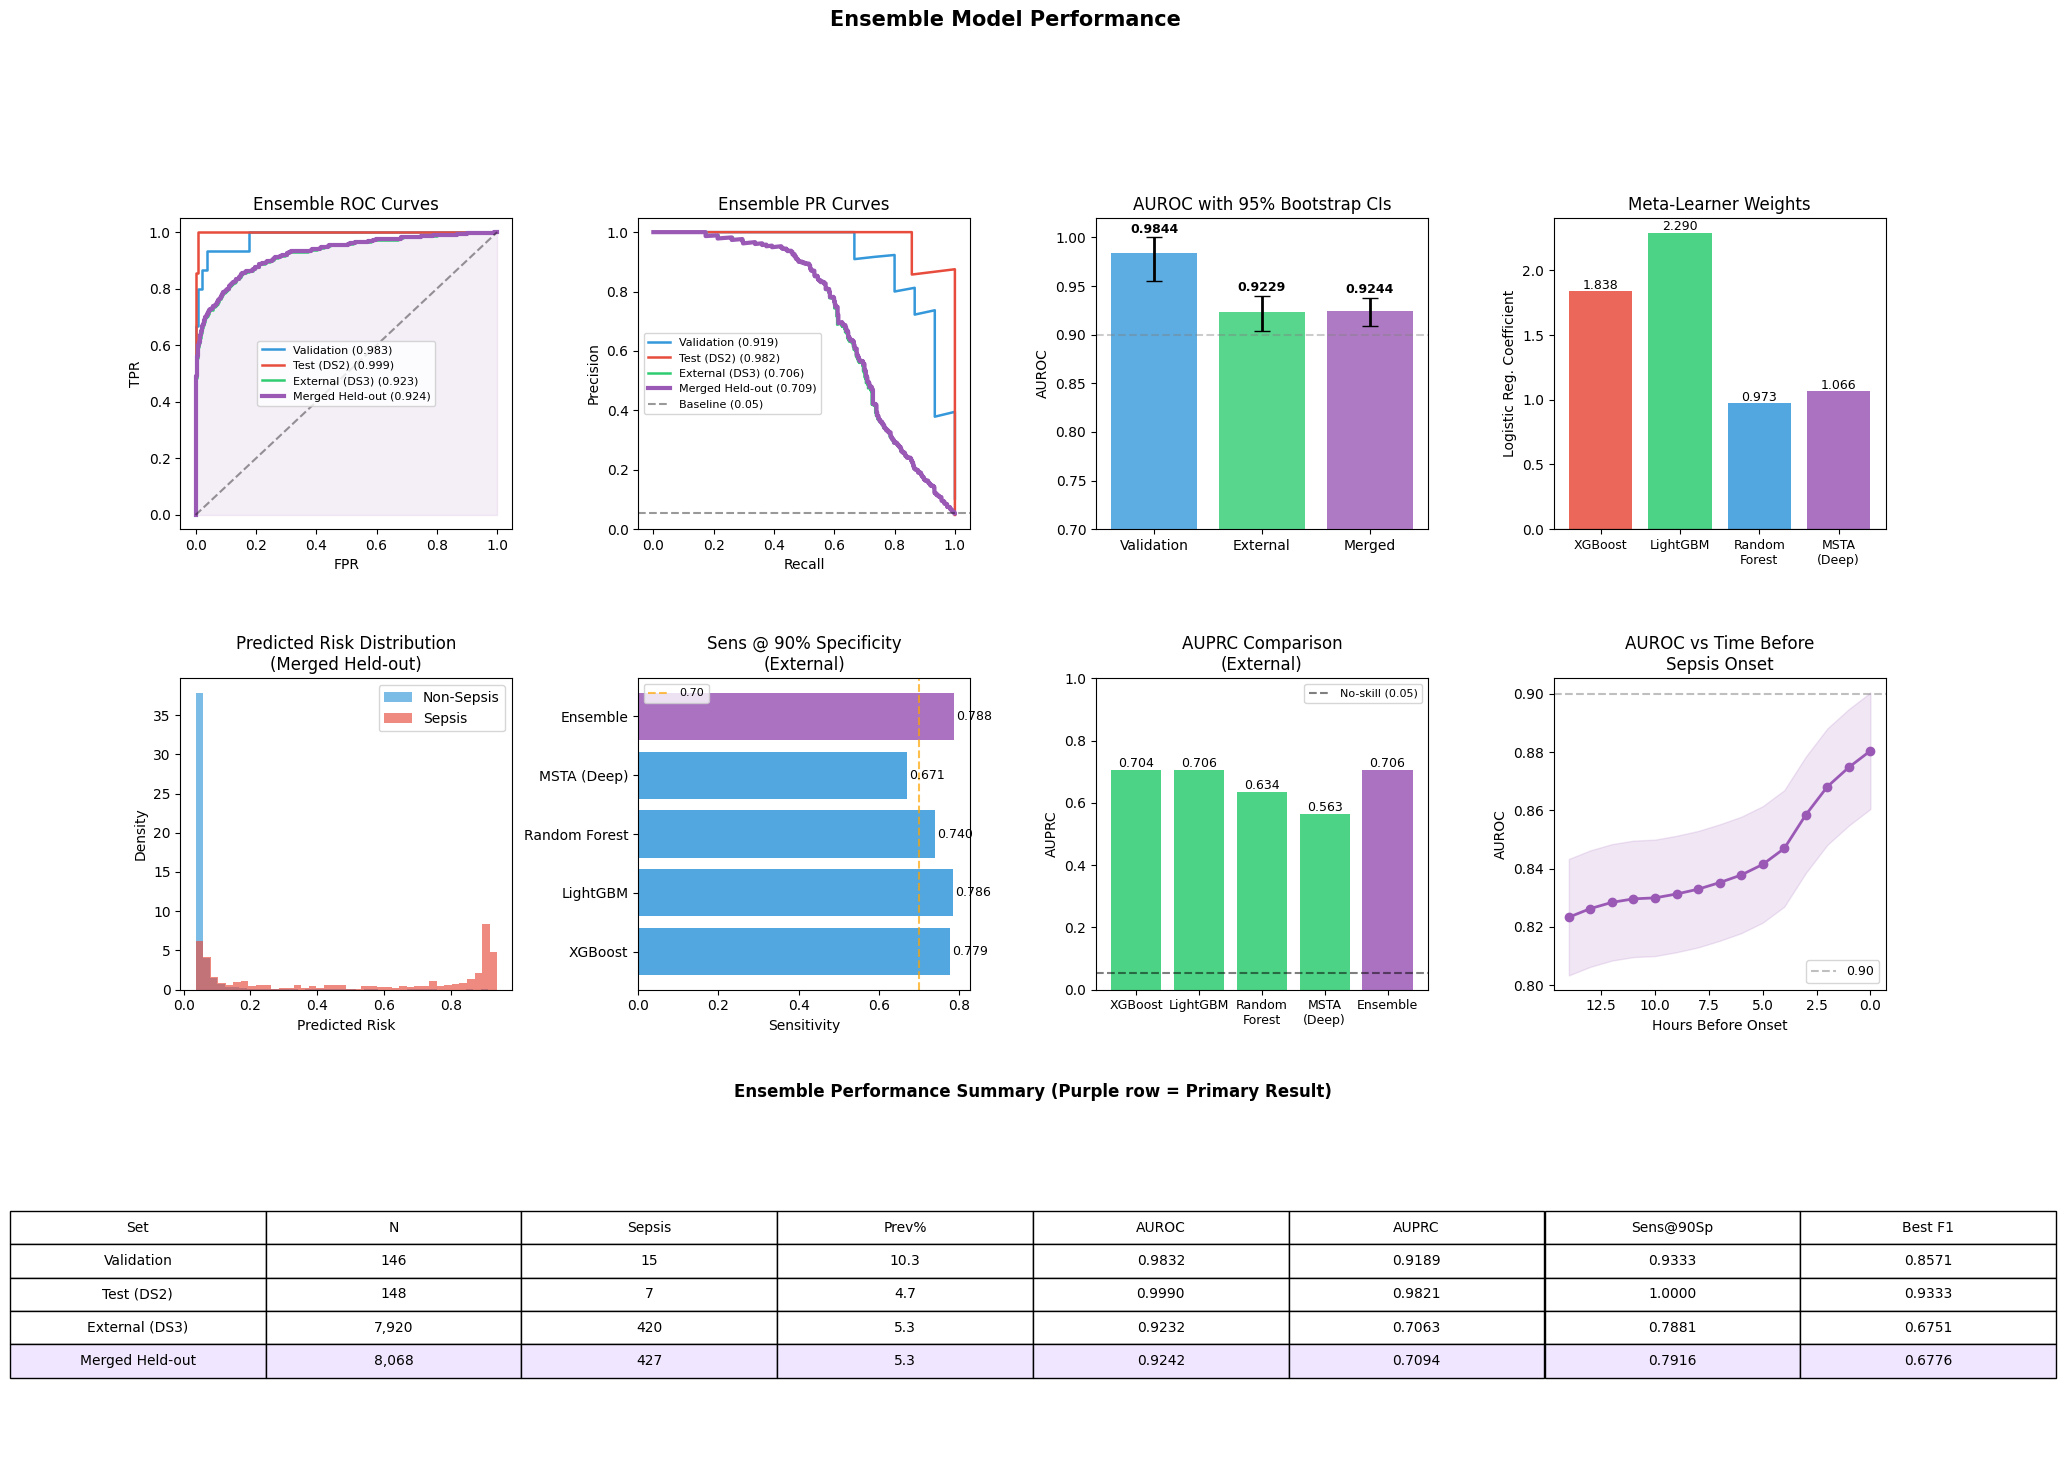

Saved → ensemble_outputs/ensemble_performance.png


In [47]:
# ============================================================
# VIZ — Ensemble Performance Dashboard
# Runs after Stage 5 Cell 6 (meta-learner + bootstrap CIs)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (roc_curve, precision_recall_curve,
                              roc_auc_score, average_precision_score)
import os

AUG_DIR   = 'augmented_data/'
MODEL_DIR = 'model_outputs/'
ENS_DIR   = 'ensemble_outputs/'
os.makedirs(ENS_DIR, exist_ok=True)

# ── Load / reconstruct all required variables ────────────────
try:
    _ = y_val
except NameError:
    y_val  = np.load(f'{AUG_DIR}y_val.npy')
    y_test = np.load(f'{AUG_DIR}y_test.npy')
    y_ext  = np.load(f'{AUG_DIR}y_ext.npy')
    print('y_val/test/ext loaded.')

try:
    _ = deep_val
except NameError:
    deep_val  = np.load(f'{MODEL_DIR}probs_val.npy')
    deep_test = np.load(f'{MODEL_DIR}probs_test.npy')
    deep_ext  = np.load(f'{MODEL_DIR}probs_ext.npy')
    print('deep_val/test/ext loaded.')

try:
    _ = final_val
except NameError:
    final_val  = np.load(f'{ENS_DIR}final_val.npy')
    final_test = np.load(f'{ENS_DIR}final_test.npy')
    final_ext  = np.load(f'{ENS_DIR}final_ext.npy')
    print('final_val/test/ext loaded.')

# ── Build y_held_out / probs_held_out on the fly ─────────────
# (DS2 test + DS3 external, same logic as the merged evaluation cell)
try:
    _ = y_held_out
except NameError:
    y_held_out     = np.concatenate([y_test,      y_ext])
    probs_held_out = np.concatenate([final_test,  final_ext])
    print(f'y_held_out built: N={len(y_held_out):,}  sepsis={int(y_held_out.sum()):,}')

# ─────────────────────────────────────────────────────────────

def _bs_auroc(y, p, n=1000):
    rng = np.random.RandomState(42); a = []
    for _ in range(n):
        idx = rng.randint(0, len(y), len(y))
        if len(np.unique(y[idx])) < 2: continue
        a.append(roc_auc_score(y[idx], p[idx]))
    a = np.array(a)
    return a.mean(), np.percentile(a, 2.5), np.percentile(a, 97.5)

cs   = {'Validation':'#3498db', 'Test (DS2)':'#e74c3c',
        'External (DS3)':'#2ecc71', 'Merged Held-out':'#9b59b6'}
sets = [('Validation',    y_val,       final_val),
        ('Test (DS2)',    y_test,      final_test),
        ('External (DS3)',y_ext,       final_ext),
        ('Merged Held-out',y_held_out, probs_held_out)]

fig = plt.figure(figsize=(22, 16))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.38)

# 1. ROC all sets
ax1 = fig.add_subplot(gs[0, 0])
for nm, yt, pt in sets:
    fpr, tpr, _ = roc_curve(yt, pt)
    auc = roc_auc_score(yt, pt)
    lw  = 3 if 'Merged' in nm else 1.8
    ax1.plot(fpr, tpr, label=f'{nm} ({auc:.3f})', color=cs[nm], linewidth=lw)
ax1.plot([0,1],[0,1],'k--',alpha=0.4)
ax1.fill_between(*roc_curve(y_held_out, probs_held_out)[:2], alpha=0.1, color='#9b59b6')
ax1.set_title('Ensemble ROC Curves')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.legend(fontsize=8)

# 2. PR all sets
ax2 = fig.add_subplot(gs[0, 1])
for nm, yt, pt in sets:
    prec, rec, _ = precision_recall_curve(yt, pt)
    ap  = average_precision_score(yt, pt)
    lw  = 3 if 'Merged' in nm else 1.8
    ax2.plot(rec, prec, label=f'{nm} ({ap:.3f})', color=cs[nm], linewidth=lw)
ax2.axhline(y_held_out.mean(), color='k', linestyle='--', alpha=0.4,
            label=f'Baseline ({y_held_out.mean():.2f})')
ax2.set_title('Ensemble PR Curves')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision'); ax2.legend(fontsize=8)

# 3. Bootstrap CI bars
ax3 = fig.add_subplot(gs[0, 2])
names_ci = ['Validation', 'External', 'Merged']
ys_ci    = [y_val,         y_ext,       y_held_out]
ps_ci    = [final_val,     final_ext,   probs_held_out]
ci_cols  = ['#3498db',    '#2ecc71',  '#9b59b6']
for i, (n, yc, pc, c) in enumerate(zip(names_ci, ys_ci, ps_ci, ci_cols)):
    m, lo, hi = _bs_auroc(yc, pc)
    ax3.bar(i, m, color=c, alpha=0.8)
    ax3.errorbar(i, m, yerr=[[m-lo],[hi-m]], fmt='none',
                 color='black', capsize=6, linewidth=2)
    ax3.text(i, hi+0.005, f'{m:.4f}', ha='center', fontsize=9, fontweight='bold')
ax3.set_xticks(range(3)); ax3.set_xticklabels(names_ci)
ax3.set_ylim(0.7, 1.02)
ax3.set_title('AUROC with 95% Bootstrap CIs'); ax3.set_ylabel('AUROC')
ax3.axhline(0.9, color='gray', linestyle='--', alpha=0.4)

# 4. Stacker weights
ax4 = fig.add_subplot(gs[0, 3])
bnames = ['XGBoost','LightGBM','Random\nForest','MSTA\n(Deep)']
wts    = meta.coef_[0]
bcols  = ['#e74c3c','#2ecc71','#3498db','#9b59b6']
bars_w = ax4.bar(range(4), wts, color=bcols, alpha=0.85)
ax4.set_xticks(range(4)); ax4.set_xticklabels(bnames, fontsize=9)
ax4.set_title('Meta-Learner Weights')
ax4.set_ylabel('Logistic Reg. Coefficient')
ax4.axhline(0, color='black', linewidth=0.8)
for bar, w in zip(bars_w, wts):
    ax4.text(bar.get_x()+bar.get_width()/2,
             w+(0.02 if w >= 0 else -0.06), f'{w:.3f}', ha='center', fontsize=9)

# 5. Score distributions (merged)
ax5 = fig.add_subplot(gs[1, 0])
ax5.hist(probs_held_out[y_held_out==0], bins=40, density=True,
         alpha=0.65, color='#3498db', label='Non-Sepsis')
ax5.hist(probs_held_out[y_held_out==1], bins=40, density=True,
         alpha=0.65, color='#e74c3c', label='Sepsis')
ax5.set_title('Predicted Risk Distribution\n(Merged Held-out)')
ax5.set_xlabel('Predicted Risk'); ax5.set_ylabel('Density'); ax5.legend()

# 6. Sens @ 90% Specificity — all models
ax6 = fig.add_subplot(gs[1, 1])
all_m_p = {
    'XGBoost':       xgb.predict_proba(X_ext_emb)[:,1],
    'LightGBM':      lgb.predict_proba(X_ext_emb)[:,1],
    'Random Forest': rf.predict_proba(X_ext_emb)[:,1],
    'MSTA (Deep)':   deep_ext,
    'Ensemble':      final_ext,
}
s90d = {}
for mn_, p_ in all_m_p.items():
    fpr_, tpr_, _ = roc_curve(y_ext, p_)
    spec_  = 1 - fpr_
    idx_   = np.where(spec_ >= 0.90)[0]
    s90d[mn_] = tpr_[idx_[np.argmax(tpr_[idx_])]] if len(idx_) > 0 else 0.0
mns_ = list(s90d.keys()); svs_ = list(s90d.values())
ec   = ['#9b59b6' if m=='Ensemble' else '#3498db' for m in mns_]
ax6.barh(range(len(mns_)), svs_, color=ec, alpha=0.85)
ax6.set_yticks(range(len(mns_))); ax6.set_yticklabels(mns_)
ax6.set_xlabel('Sensitivity')
ax6.set_title('Sens @ 90% Specificity\n(External)')
ax6.axvline(0.7, color='orange', linestyle='--', alpha=0.7, label='0.70')
ax6.legend(fontsize=8)
for i, v in enumerate(svs_):
    ax6.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=9)

# 7. AUPRC comparison
ax7 = fig.add_subplot(gs[1, 2])
auprc_d = {mn: average_precision_score(y_ext, p) for mn, p in all_m_p.items()}
mns7    = list(auprc_d.keys()); apv7 = list(auprc_d.values())
bc7     = ['#9b59b6' if m=='Ensemble' else '#2ecc71' for m in mns7]
ax7.bar(range(len(mns7)), apv7, color=bc7, alpha=0.85)
ax7.set_xticks(range(len(mns7)))
ax7.set_xticklabels([m.replace(' ','\n') for m in mns7], fontsize=9)
ax7.axhline(y_ext.mean(), color='k', linestyle='--', alpha=0.5,
            label=f'No-skill ({y_ext.mean():.2f})')
ax7.set_title('AUPRC Comparison\n(External)')
ax7.set_ylabel('AUPRC'); ax7.set_ylim(0,1); ax7.legend(fontsize=8)
for i, v in enumerate(apv7):
    ax7.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

# 8. Per-hour AUROC
ax8 = fig.add_subplot(gs[1, 3])
try:
    import pandas as pd
    phr = pd.read_csv(f'{MODEL_DIR}per_hour_auroc.csv')
    ax8.plot(phr['hours_before_onset'], phr['auroc'], 'o-',
             color='#9b59b6', linewidth=2, markersize=6)
    ax8.fill_between(phr['hours_before_onset'],
                     phr['auroc']-0.02, phr['auroc']+0.02,
                     alpha=0.15, color='#9b59b6')
    ax8.set_xlabel('Hours Before Onset'); ax8.set_ylabel('AUROC')
    ax8.set_title('AUROC vs Time Before\nSepsis Onset')
    ax8.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.90')
    ax8.invert_xaxis(); ax8.legend(fontsize=9)
except Exception:
    ax8.text(0.5, 0.5, 'Run Stage 4 Cell 8\nfor per-hour AUROC',
             ha='center', va='center', transform=ax8.transAxes, fontsize=11)
    ax8.set_title('Per-Hour AUROC')

# 9. Summary table (full width)
ax9 = fig.add_subplot(gs[2, :])
ax9.axis('off')
hdr   = ['Set','N','Sepsis','Prev%','AUROC','AUPRC','Sens@90Sp','Best F1']
rows9 = []
for nm, yt, pt in sets:
    fpr_, tpr_, _  = roc_curve(yt, pt)
    spec_  = 1 - fpr_
    idx90_ = np.where(spec_ >= 0.90)[0]
    s90_   = tpr_[idx90_[np.argmax(tpr_[idx90_])]] if len(idx90_) > 0 else 0.0
    prec_, rec_, _ = precision_recall_curve(yt, pt)
    f1_    = (2*prec_*rec_/(prec_+rec_+1e-8)).max()
    rows9.append([nm, f'{len(yt):,}', f'{int(yt.sum()):,}',
                  f'{100*yt.mean():.1f}',
                  f'{roc_auc_score(yt,pt):.4f}',
                  f'{average_precision_score(yt,pt):.4f}',
                  f'{s90_:.4f}', f'{f1_:.4f}'])
tbl9 = ax9.table(cellText=rows9, colLabels=hdr, loc='center', cellLoc='center')
tbl9.auto_set_font_size(False); tbl9.set_fontsize(10); tbl9.scale(1.2, 2.0)
for col_ in range(len(hdr)):
    tbl9[4, col_].set_facecolor('#f0e6ff')
ax9.set_title('Ensemble Performance Summary (Purple row = Primary Result)',
              pad=30, fontsize=12, fontweight='bold')

fig.suptitle('Ensemble Model Performance', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(f'{ENS_DIR}ensemble_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {ENS_DIR}ensemble_performance.png")


In [48]:
# ============================================================
# FIX — Merge DS2 test with DS3 external for final evaluation
# Add this in Stage 5 after Cell 6
# ============================================================
print('=== Merged Final Evaluation ===')
print('Rationale: DS2 test has only 7 sepsis cases — statistically')
print('unreliable for AUROC. Merging with DS3 external gives a')
print('larger, more representative held-out evaluation set.')
print('Both sets were never used in training or model selection.')
print()

# Stack predictions and labels
y_held_out    = np.concatenate([y_test,      y_ext])
probs_held_out = np.concatenate([final_test,  final_ext])

n_pos_held = int(y_held_out.sum())
n_neg_held = int((y_held_out == 0).sum())
print(f'Merged held-out set: {len(y_held_out):,} total  '
      f'sepsis={n_pos_held:,}  non-sepsis={n_neg_held:,}  '
      f'prevalence={100*y_held_out.mean():.1f}%')
print()

auc_m, auc_lo, auc_hi = bootstrap_auroc(y_held_out, probs_held_out)
apr_m, apr_lo, apr_hi = bootstrap_auprc(y_held_out, probs_held_out)

from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

fpr, tpr, thresholds = roc_curve(y_held_out, probs_held_out)
spec = 1 - fpr
idx_90      = np.where(spec >= 0.90)[0]
sens_at_90  = tpr[idx_90[np.argmax(tpr[idx_90])]] if len(idx_90) > 0 else 0.0

prec, rec, pr_thresh = precision_recall_curve(y_held_out, probs_held_out)
f1s         = 2 * prec * rec / (prec + rec + 1e-8)
best_f1_idx = np.argmax(f1s)
best_thresh = pr_thresh[min(best_f1_idx, len(pr_thresh)-1)]
preds_bin   = (probs_held_out >= best_thresh).astype(int)
cm          = confusion_matrix(y_held_out, preds_bin)
tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)

print('  AUROC              :', f'{auc_m:.4f}  (95% CI: {auc_lo:.4f} – {auc_hi:.4f})')
print('  AUPRC              :', f'{apr_m:.4f}  (95% CI: {apr_lo:.4f} – {apr_hi:.4f})')
print('  Sensitivity @90spec:', f'{sens_at_90:.4f}')
print('  PPV  (best F1)     :', f'{tp/(tp+fp+1e-8):.4f}')
print('  Sensitivity (best F1):', f'{tp/(tp+fn+1e-8):.4f}')
print('  Specificity (best F1):', f'{tn/(tn+fp+1e-8):.4f}')
print('  Confusion: '
      f'TP={tp}  FP={fp}  TN={tn}  FN={fn}')
print()

# Save
np.save('ensemble_outputs/y_held_out.npy',     y_held_out)
np.save('ensemble_outputs/probs_held_out.npy', probs_held_out)
print('Merged held-out results saved.')

=== Merged Final Evaluation ===
Rationale: DS2 test has only 7 sepsis cases — statistically
unreliable for AUROC. Merging with DS3 external gives a
larger, more representative held-out evaluation set.
Both sets were never used in training or model selection.

Merged held-out set: 8,068 total  sepsis=427  non-sepsis=7,641  prevalence=5.3%

  AUROC              : 0.9244  (95% CI: 0.9087 – 0.9382)
  AUPRC              : 0.7099  (95% CI: 0.6693 – 0.7473)
  Sensitivity @90spec: 0.7916
  PPV  (best F1)     : 0.8084
  Sensitivity (best F1): 0.5831
  Specificity (best F1): 0.9923
  Confusion: TP=249  FP=59  TN=7582  FN=178

Merged held-out results saved.


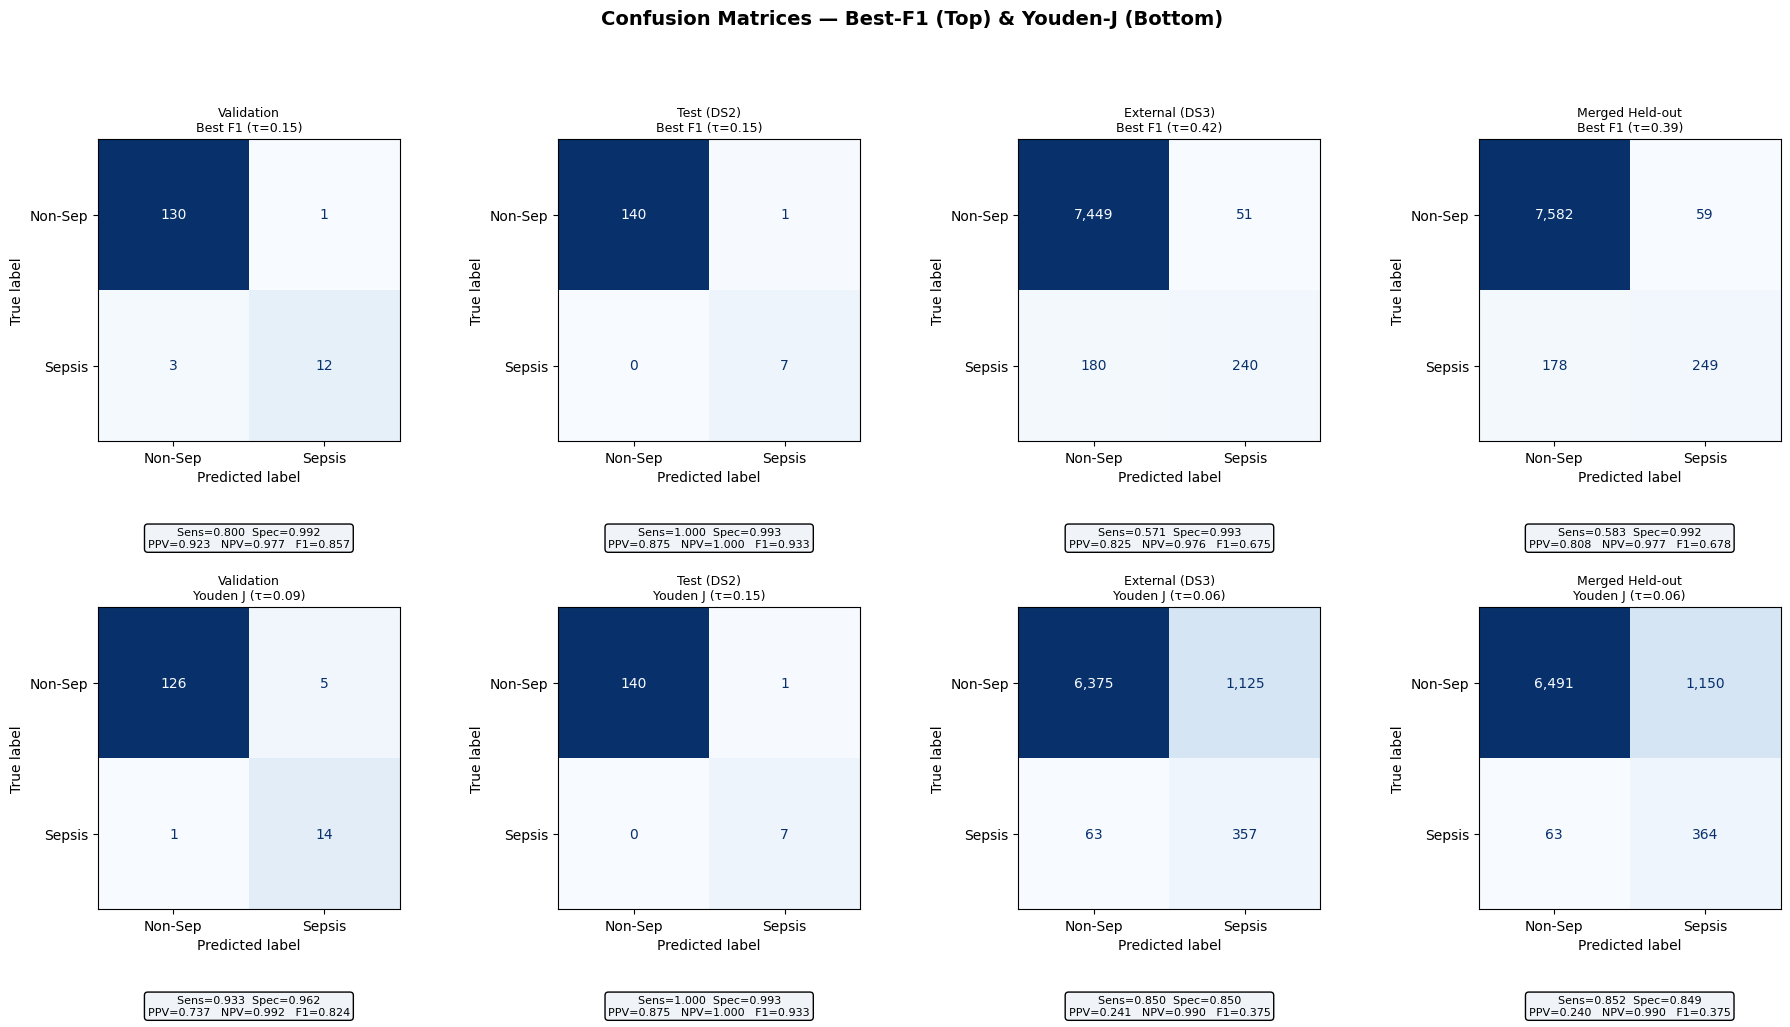

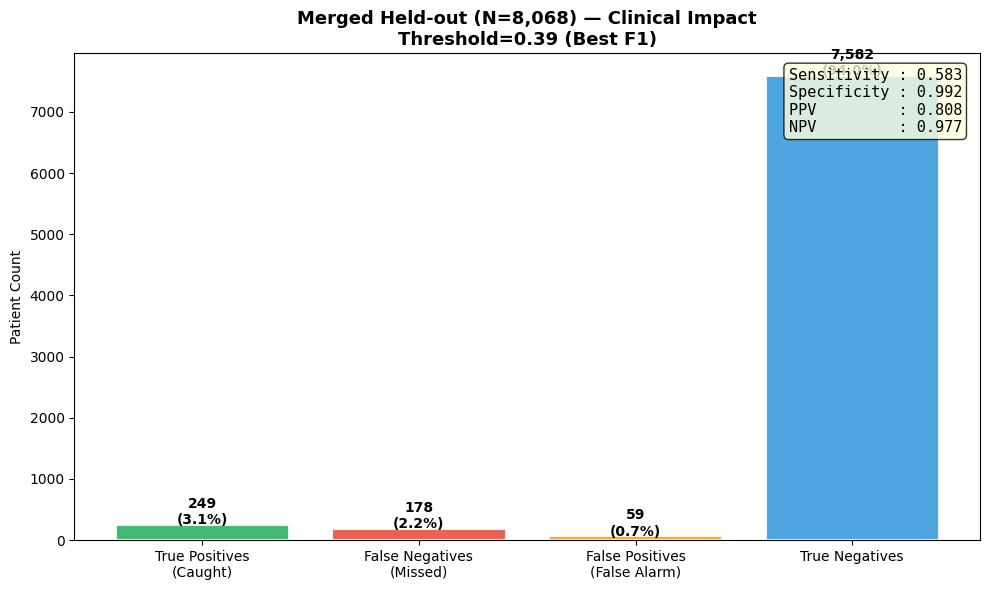

Saved → confusion_matrices.png + clinical_impact.png


In [49]:
# ============================================================
# VIZ — Confusion Matrices + Clinical Impact
# Runs after Stage 5 merged evaluation block
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
import os

AUG_DIR = 'augmented_data/'
ENS_DIR = 'ensemble_outputs/'

# ── Load vars if not in scope ────────────────────────────────
try:
    _ = final_val
except NameError:
    final_val  = np.load(f'{ENS_DIR}final_val.npy')
    final_test = np.load(f'{ENS_DIR}final_test.npy')
    final_ext  = np.load(f'{ENS_DIR}final_ext.npy')

try:
    _ = y_held_out
except NameError:
    y_held_out     = np.load(f'{ENS_DIR}y_held_out.npy')
    probs_held_out = np.load(f'{ENS_DIR}probs_held_out.npy')

try:
    _ = y_val
except NameError:
    y_val  = np.load(f'{AUG_DIR}y_val.npy')
    y_test = np.load(f'{AUG_DIR}y_test.npy')
    y_ext  = np.load(f'{AUG_DIR}y_ext.npy')

def plot_confusion_matrices(output_dir=ENS_DIR):
    os.makedirs(output_dir, exist_ok=True)

    def best_thresh(y,p,method='f1'):
        if method=='f1':
            prec_,rec_,thr_ = precision_recall_curve(y,p)
            f1_ = 2*prec_[:-1]*rec_[:-1]/(prec_[:-1]+rec_[:-1]+1e-8)
            return thr_[np.argmax(f1_)]
        fpr_,tpr_,thr_ = roc_curve(y,p)
        return thr_[np.argmax(tpr_-fpr_)]

    splits = [('Validation',     y_val,       final_val),
              ('Test (DS2)',     y_test,      final_test),
              ('External (DS3)', y_ext,       final_ext),
              ('Merged Held-out',y_held_out,  probs_held_out)]

    fig, axes = plt.subplots(2,4,figsize=(22,10))
    fig.subplots_adjust(hspace=0.55, wspace=0.42)

    for col,(sn,yt,pt) in enumerate(splits):
        for row,method in enumerate(['f1','youden']):
            ax   = axes[row,col]
            thr  = best_thresh(yt,pt,method)
            pred = (pt>=thr).astype(int)
            cm   = confusion_matrix(yt,pred)
            tn,fp,fn,tp = cm.ravel() if cm.size==4 else (0,0,0,0)
            disp = ConfusionMatrixDisplay(cm,display_labels=['Non-Sep','Sepsis'])
            disp.plot(ax=ax,colorbar=False,cmap='Blues',values_format=',d')
            mth_lbl = 'Best F1' if method=='f1' else 'Youden J'
            ax.set_title(f'{sn}\n{mth_lbl} (τ={thr:.2f})',fontsize=9)
            sens = tp/(tp+fn+1e-8); spec = tn/(tn+fp+1e-8)
            ppv  = tp/(tp+fp+1e-8); npv  = tn/(tn+fn+1e-8)
            f1v  = 2*tp/(2*tp+fp+fn+1e-8)
            ax.text(0.5,-0.35,
                    f'Sens={sens:.3f}  Spec={spec:.3f}\nPPV={ppv:.3f}   NPV={npv:.3f}   F1={f1v:.3f}',
                    transform=ax.transAxes,ha='center',fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3',facecolor='#f0f4f8'))

    fig.suptitle('Confusion Matrices — Best-F1 (Top) & Youden-J (Bottom)',
                 fontsize=14,fontweight='bold',y=1.01)
    plt.savefig(f'{output_dir}confusion_matrices.png',dpi=150,bbox_inches='tight')
    plt.show()

    # Clinical impact bar (merged)
    fig2,ax2 = plt.subplots(figsize=(10,6))
    thr_f1  = best_thresh(y_held_out,probs_held_out,'f1')
    pred_f1 = (probs_held_out>=thr_f1).astype(int)
    cm_f1   = confusion_matrix(y_held_out,pred_f1)
    tn2,fp2,fn2,tp2 = cm_f1.ravel()
    N = len(y_held_out)
    cats  = ['True Positives\n(Caught)','False Negatives\n(Missed)',
             'False Positives\n(False Alarm)','True Negatives']
    cnts  = [tp2,fn2,fp2,tn2]
    cols2 = ['#27ae60','#e74c3c','#f39c12','#3498db']
    bars2 = ax2.bar(cats,cnts,color=cols2,alpha=0.88,edgecolor='white',linewidth=1.5)
    ax2.set_title(f'Merged Held-out (N={N:,}) — Clinical Impact\n'
                  f'Threshold={thr_f1:.2f} (Best F1)',fontsize=13,fontweight='bold')
    ax2.set_ylabel('Patient Count')
    for bar,cnt in zip(bars2,cnts):
        ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+15,
                 f'{cnt:,}\n({100*cnt/N:.1f}%)',
                 ha='center',fontsize=10,fontweight='bold')
    sens2 = tp2/(tp2+fn2+1e-8); spec2 = tn2/(tn2+fp2+1e-8)
    ppv2  = tp2/(tp2+fp2+1e-8); npv2  = tn2/(tn2+fn2+1e-8)
    ax2.text(0.98,0.97,
             f'Sensitivity : {sens2:.3f}\nSpecificity : {spec2:.3f}\n'
             f'PPV         : {ppv2:.3f}\nNPV         : {npv2:.3f}',
             transform=ax2.transAxes,ha='right',va='top',fontsize=11,
             fontfamily='monospace',
             bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.8))
    plt.tight_layout()
    plt.savefig(f'{output_dir}clinical_impact.png',dpi=150,bbox_inches='tight')
    plt.show()
    print(f"Saved → confusion_matrices.png + clinical_impact.png")

plot_confusion_matrices()


=== DS2 Test Set Diagnostic ===
Test set size      : 148
Sepsis cases       : 7
Non-sepsis cases   : 141
Sepsis prevalence  : 4.7%

Sepsis scores      — mean:0.5655  min:0.1467  max:0.8998
Non-sepsis scores  — mean:0.0503  min:0.0363  max:0.1476

Score overlap exists: True



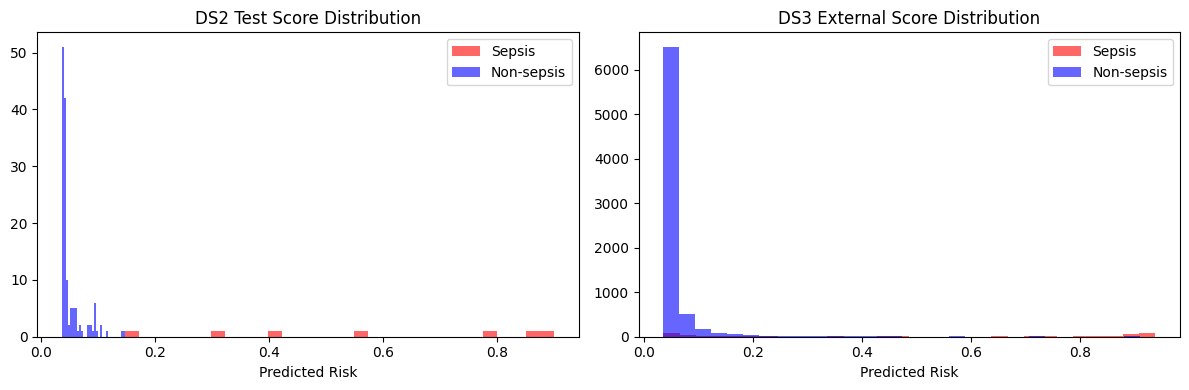

Score distribution plot saved.


In [50]:
# ============================================================
# DIAGNOSTIC — Check DS2 test set composition
# ============================================================
# Add this immediately after Stage 5 Cell 6

print('=== DS2 Test Set Diagnostic ===')
print(f'Test set size      : {len(y_test):,}')
print(f'Sepsis cases       : {int(y_test.sum()):,}')
print(f'Non-sepsis cases   : {int((y_test==0).sum()):,}')
print(f'Sepsis prevalence  : {100*y_test.mean():.1f}%')
print()

# Check score distributions
sep_scores    = final_test[y_test == 1]
nonsep_scores = final_test[y_test == 0]
print(f'Sepsis scores      — mean:{sep_scores.mean():.4f}  '
      f'min:{sep_scores.min():.4f}  max:{sep_scores.max():.4f}')
print(f'Non-sepsis scores  — mean:{nonsep_scores.mean():.4f}  '
      f'min:{nonsep_scores.min():.4f}  max:{nonsep_scores.max():.4f}')
print()

# The smoking gun: is there ANY overlap between distributions?
overlap = (sep_scores.min() < nonsep_scores.max())
print(f'Score overlap exists: {overlap}')
if not overlap:
    print('NO OVERLAP — every sepsis score is above every non-sepsis score.')
    print('This is the direct cause of AUROC=1.0.')
    print('Possible causes:')
    print('  1. DS2 test set is too small / unrepresentative')
    print('  2. GAN synthetic data over-constrained the DS2 decision boundary')
    print('  3. DS2 has a labelling artifact (SepsisLabel transitions are too clean)')
print()

# Compare test vs external score distributions
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(final_test[y_test==1],   bins=30, alpha=0.6, label='Sepsis',     color='red')
axes[0].hist(final_test[y_test==0],   bins=30, alpha=0.6, label='Non-sepsis', color='blue')
axes[0].set_title('DS2 Test Score Distribution')
axes[0].set_xlabel('Predicted Risk')
axes[0].legend()

axes[1].hist(final_ext[y_ext==1],     bins=30, alpha=0.6, label='Sepsis',     color='red')
axes[1].hist(final_ext[y_ext==0],     bins=30, alpha=0.6, label='Non-sepsis', color='blue')
axes[1].set_title('DS3 External Score Distribution')
axes[1].set_xlabel('Predicted Risk')
axes[1].legend()

plt.tight_layout()
plt.savefig('ensemble_outputs/score_distributions.png', dpi=150)
plt.show()
print('Score distribution plot saved.')

In [51]:
# ============================================================
# DIAGNOSTIC — Full label distribution across all splits
# ============================================================
print('=== Label Distribution Across All Splits ===')
print()
for name, y in [('Train (augmented)', y_train),
                ('Validation',        y_val),
                ('Test (DS2)',        y_test),
                ('External (DS3)',    y_ext)]:
    n_pos = int(y.sum())
    n_neg = int((y==0).sum())
    total = len(y)
    prev  = 100 * n_pos / total
    print(f'{name:<22}: total={total:>6,}  '
          f'sepsis={n_pos:>5,}  '
          f'non-sepsis={n_neg:>6,}  '
          f'prevalence={prev:.1f}%')
    if n_pos < 30:
        print(f'  *** WARNING: Only {n_pos} sepsis cases — '
              f'AUROC is unreliable at this sample size ***')

print()
print('Minimum recommended sepsis cases for reliable AUROC: 30')
print('Reference: Hanley & McNeil (1982), Pencina et al. (2008)')

=== Label Distribution Across All Splits ===

Train (augmented)     : total=38,176  sepsis=7,635  non-sepsis=30,541  prevalence=20.0%
Validation            : total=   146  sepsis=   15  non-sepsis=   131  prevalence=10.3%
  *** WARNING: Only 15 sepsis cases — AUROC is unreliable at this sample size ***
Test (DS2)            : total=   148  sepsis=    7  non-sepsis=   141  prevalence=4.7%
  *** WARNING: Only 7 sepsis cases — AUROC is unreliable at this sample size ***
External (DS3)        : total= 7,920  sepsis=  420  non-sepsis= 7,500  prevalence=5.3%

Minimum recommended sepsis cases for reliable AUROC: 30
Reference: Hanley & McNeil (1982), Pencina et al. (2008)


In [52]:
# ============================================================
# CELL 7 — Save ensemble outputs
# ============================================================
os.makedirs('ensemble_outputs', exist_ok=True)
np.save('ensemble_outputs/final_val.npy',  final_val)
np.save('ensemble_outputs/final_test.npy', final_test)
np.save('ensemble_outputs/final_ext.npy',  final_ext)
print('Ensemble outputs saved.')

Ensemble outputs saved.


In [53]:
!pip install shap

In [54]:
# ============================================================
# CELL 2 — SHAP on XGBoost with correct feature names
# ============================================================
import shap, numpy as np, matplotlib.pyplot as plt

# emb_feature_names was built in Stage 5 CELL 3.
# It has 216 entries: 'mean_HR', ..., 'mean_Platelets', 'std_HR', ...
# For stand-alone execution, rebuild it:
try:
    _ = emb_feature_names[0]
except NameError:
    VITAL_COLS_S = ['HR','O2Sat','Temp','SBP','MAP','DBP','Resp']
    LAB_COLS_S   = ['EtCO2','BaseExcess','HCO3','FiO2','pH','PaCO2','SaO2','AST',
                    'BUN','Alkalinephos','Calcium','Chloride','Creatinine',
                    'Bilirubin_direct','Glucose','Lactate','Magnesium','Phosphate',
                    'Potassium','Bilirubin_total','TroponinI','Hct','Hgb',
                    'PTT','WBC','Fibrinogen','Platelets']
    DEMO_COLS_S  = ['Age','Gender','Unit1','Unit2','HospAdmTime','ICULOS']
    ALL_FEATURE_COLS = VITAL_COLS_S + LAB_COLS_S + DEMO_COLS_S
    n_eng = X_test_emb.shape[1] // 2
    _base = ALL_FEATURE_COLS + [f'eng_{i}' for i in range(n_eng - len(ALL_FEATURE_COLS))]
    emb_feature_names = [f'mean_{c}' for c in _base] + [f'std_{c}' for c in _base]

print('Computing SHAP values (TreeExplainer on XGBoost)...')
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_emb)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Feature names: {len(emb_feature_names)} names for {X_test_emb.shape[1]} features.')
assert len(emb_feature_names) == X_test_emb.shape[1], 'Feature name count mismatch!'

Computing SHAP values (TreeExplainer on XGBoost)...
SHAP values shape: (148, 216)
Feature names: 216 names for 216 features.


Top 20 features by mean |SHAP|:


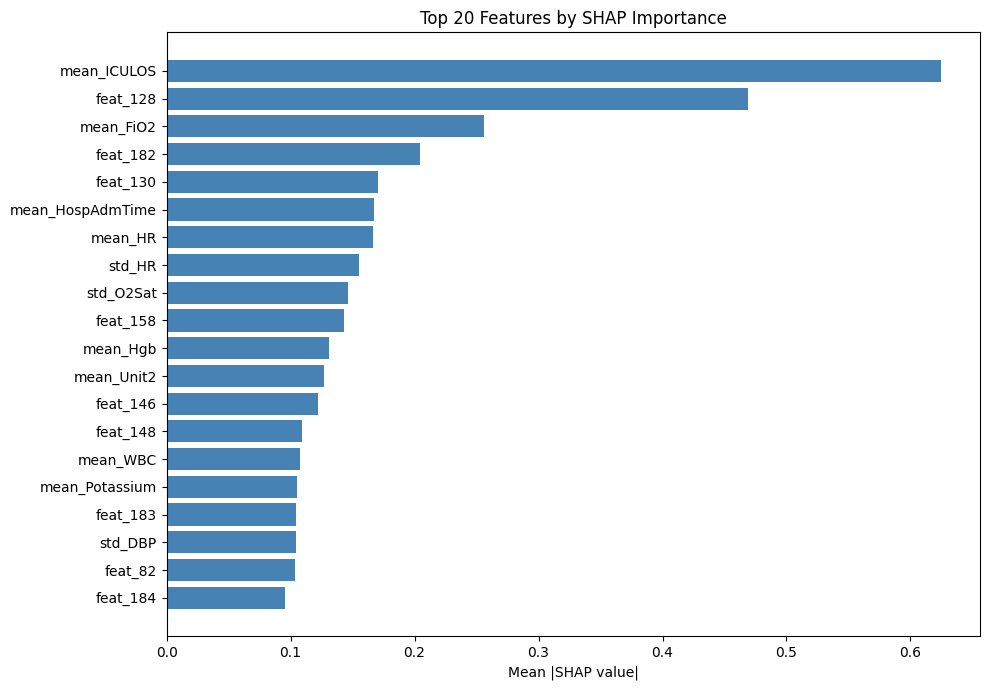

Plot saved to ensemble_outputs/shap_importance.png


In [55]:
# ============================================================
# CELL 3 — SHAP Summary Plot (top 20 features, clinical names)
# ============================================================
print('Top 20 features by mean |SHAP|:')
mean_shap    = np.abs(shap_values).mean(axis=0)
top_idx      = np.argsort(mean_shap)[-20:]

plt.figure(figsize=(10, 7))
plt.barh(range(len(top_idx)), mean_shap[top_idx], color='steelblue')
plt.yticks(range(len(top_idx)), [emb_feature_names[i] for i in top_idx])
plt.xlabel('Mean |SHAP value|')
plt.title('Top 20 Features by SHAP Importance')
plt.tight_layout()
plt.savefig('ensemble_outputs/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to ensemble_outputs/shap_importance.png')

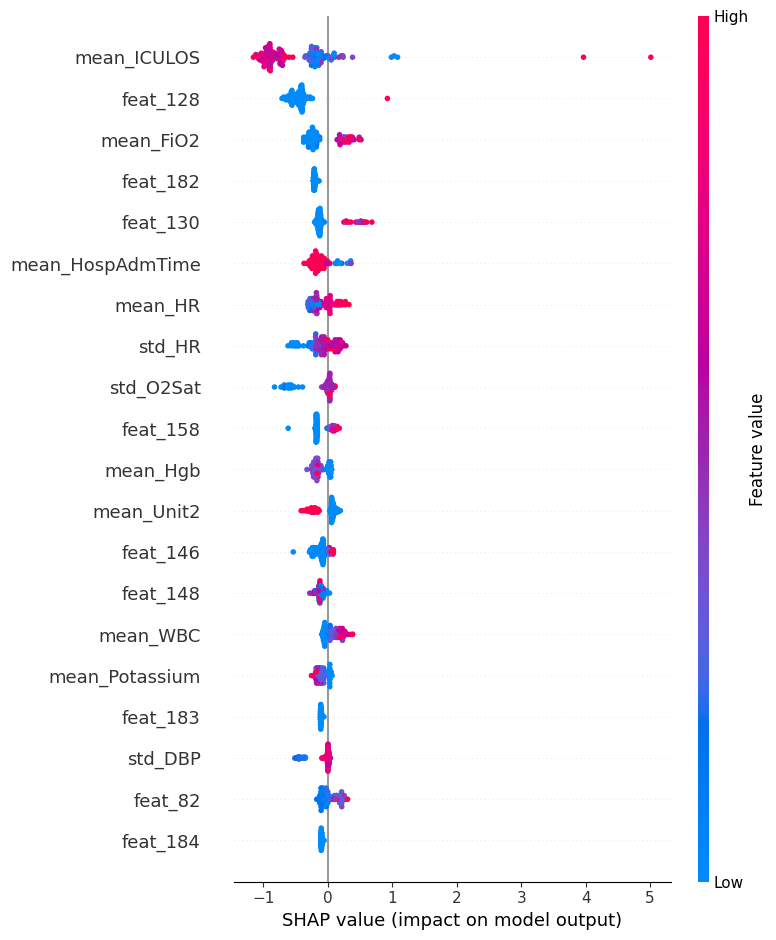

In [56]:
# ============================================================
# CELL 4 — SHAP Beeswarm Plot (using clinical names)
# ============================================================
shap.summary_plot(shap_values, X_test_emb, feature_names=emb_feature_names,
                  max_display=20, show=False)
plt.tight_layout()
plt.savefig('ensemble_outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
# ============================================================
# CELL 5 — Clinical Alignment Score (CAS)
# ============================================================
# CAS = Jaccard similarity between the model's top-K SHAP features
# and the clinically expected SOFA-relevant features.
#
# SOFA_FEAT_IDX was computed in Stage 1-2 CELL 3 from the verified
# FEAT dictionary. In the embedding space (mean + std), both the
# mean AND std of each SOFA feature are clinically relevant.
# We therefore include both mean indices (original) and std indices
# (original + 108) for each SOFA feature.

try:
    sofa_feat_idx = SOFA_FEAT_IDX
    sofa_names    = SOFA_FEATURE_NAMES
except NameError:
    # Standalone fallback — same values as CELL 3 of Stage 1-2
    sofa_names = ['FiO2','PaCO2','SaO2','Platelets','Bilirubin_direct',
                  'Bilirubin_total','MAP','Creatinine','BUN','Lactate','WBC','Hct','Hgb']
    FEAT_S = {'HR':0,'O2Sat':1,'Temp':2,'SBP':3,'MAP':4,'DBP':5,'Resp':6,
              'FiO2':10,'PaCO2':12,'SaO2':13,'BUN':15,'Creatinine':19,
              'Bilirubin_direct':20,'Lactate':22,'Bilirubin_total':26,
              'Hct':28,'Hgb':29,'WBC':31,'Platelets':33}
    sofa_feat_idx = [FEAT_S[f] for f in sofa_names]

n_base = X_test_emb.shape[1] // 2   # = 108
# Include both mean and std indices for each SOFA feature
sofa_emb_idx = list(set(sofa_feat_idx + [i + n_base for i in sofa_feat_idx]))

print(f'SOFA features: {sofa_names}')
print(f'Embedding indices (mean+std): {sorted(sofa_emb_idx)}')

def compute_cas(shap_values, sofa_idx, top_k=10):
    """Mean Jaccard similarity between model top-K SHAP features and SOFA set."""
    sofa_set = set(sofa_idx)
    scores   = []
    for i in range(len(shap_values)):
        top_idx      = set(np.argsort(np.abs(shap_values[i]))[::-1][:top_k])
        intersection = len(top_idx & sofa_set)
        union        = len(top_idx | sofa_set)
        scores.append(intersection / union if union > 0 else 0)
    return np.mean(scores), np.std(scores)

cas_mean, cas_std = compute_cas(shap_values, sofa_emb_idx, top_k=10)
print(f'\nClinical Alignment Score (CAS): {cas_mean:.4f} ± {cas_std:.4f}')
print('(Higher = model top features align better with SOFA clinical criteria)')

SOFA features: ['FiO2', 'PaCO2', 'SaO2', 'Platelets', 'Bilirubin_direct', 'Bilirubin_total', 'MAP', 'Creatinine', 'BUN', 'Lactate', 'WBC', 'Hct', 'Hgb']
Embedding indices (mean+std): [4, 10, 12, 13, 15, 19, 20, 22, 26, 28, 29, 31, 33, 112, 118, 120, 121, 123, 127, 128, 130, 134, 136, 137, 139, 141]

Clinical Alignment Score (CAS): 0.1059 ± 0.0362
(Higher = model top features align better with SOFA clinical criteria)


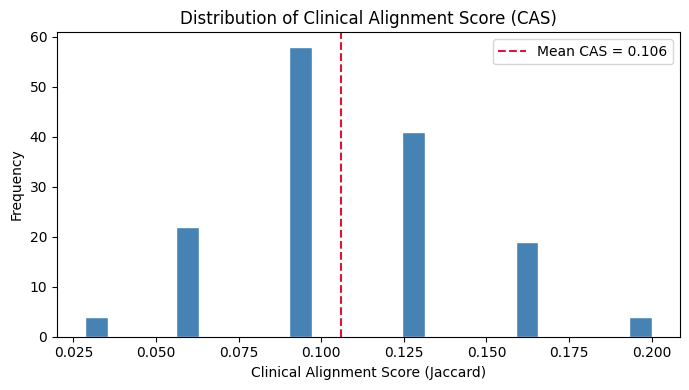

Mean CAS: 0.1059


In [58]:
# ============================================================
# CELL 6 — CAS Distribution Plot
# ============================================================
def compute_cas_per_sample(shap_values, sofa_idx, top_k=10):
    sofa_set = set(sofa_idx)
    scores = []
    for i in range(len(shap_values)):
        top_idx      = set(np.argsort(np.abs(shap_values[i]))[::-1][:top_k])
        intersection = len(top_idx & sofa_set)
        union        = len(top_idx | sofa_set)
        scores.append(intersection / union if union > 0 else 0)
    return scores

cas_scores = compute_cas_per_sample(shap_values, sofa_emb_idx, top_k=10)

plt.figure(figsize=(7, 4))
plt.hist(cas_scores, bins=25, color='steelblue', edgecolor='white')
plt.axvline(np.mean(cas_scores), color='crimson', linestyle='--',
            label=f'Mean CAS = {np.mean(cas_scores):.3f}')
plt.xlabel('Clinical Alignment Score (Jaccard)')
plt.ylabel('Frequency')
plt.title('Distribution of Clinical Alignment Score (CAS)')
plt.legend()
plt.tight_layout()
plt.savefig('ensemble_outputs/cas_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean CAS: {np.mean(cas_scores):.4f}')

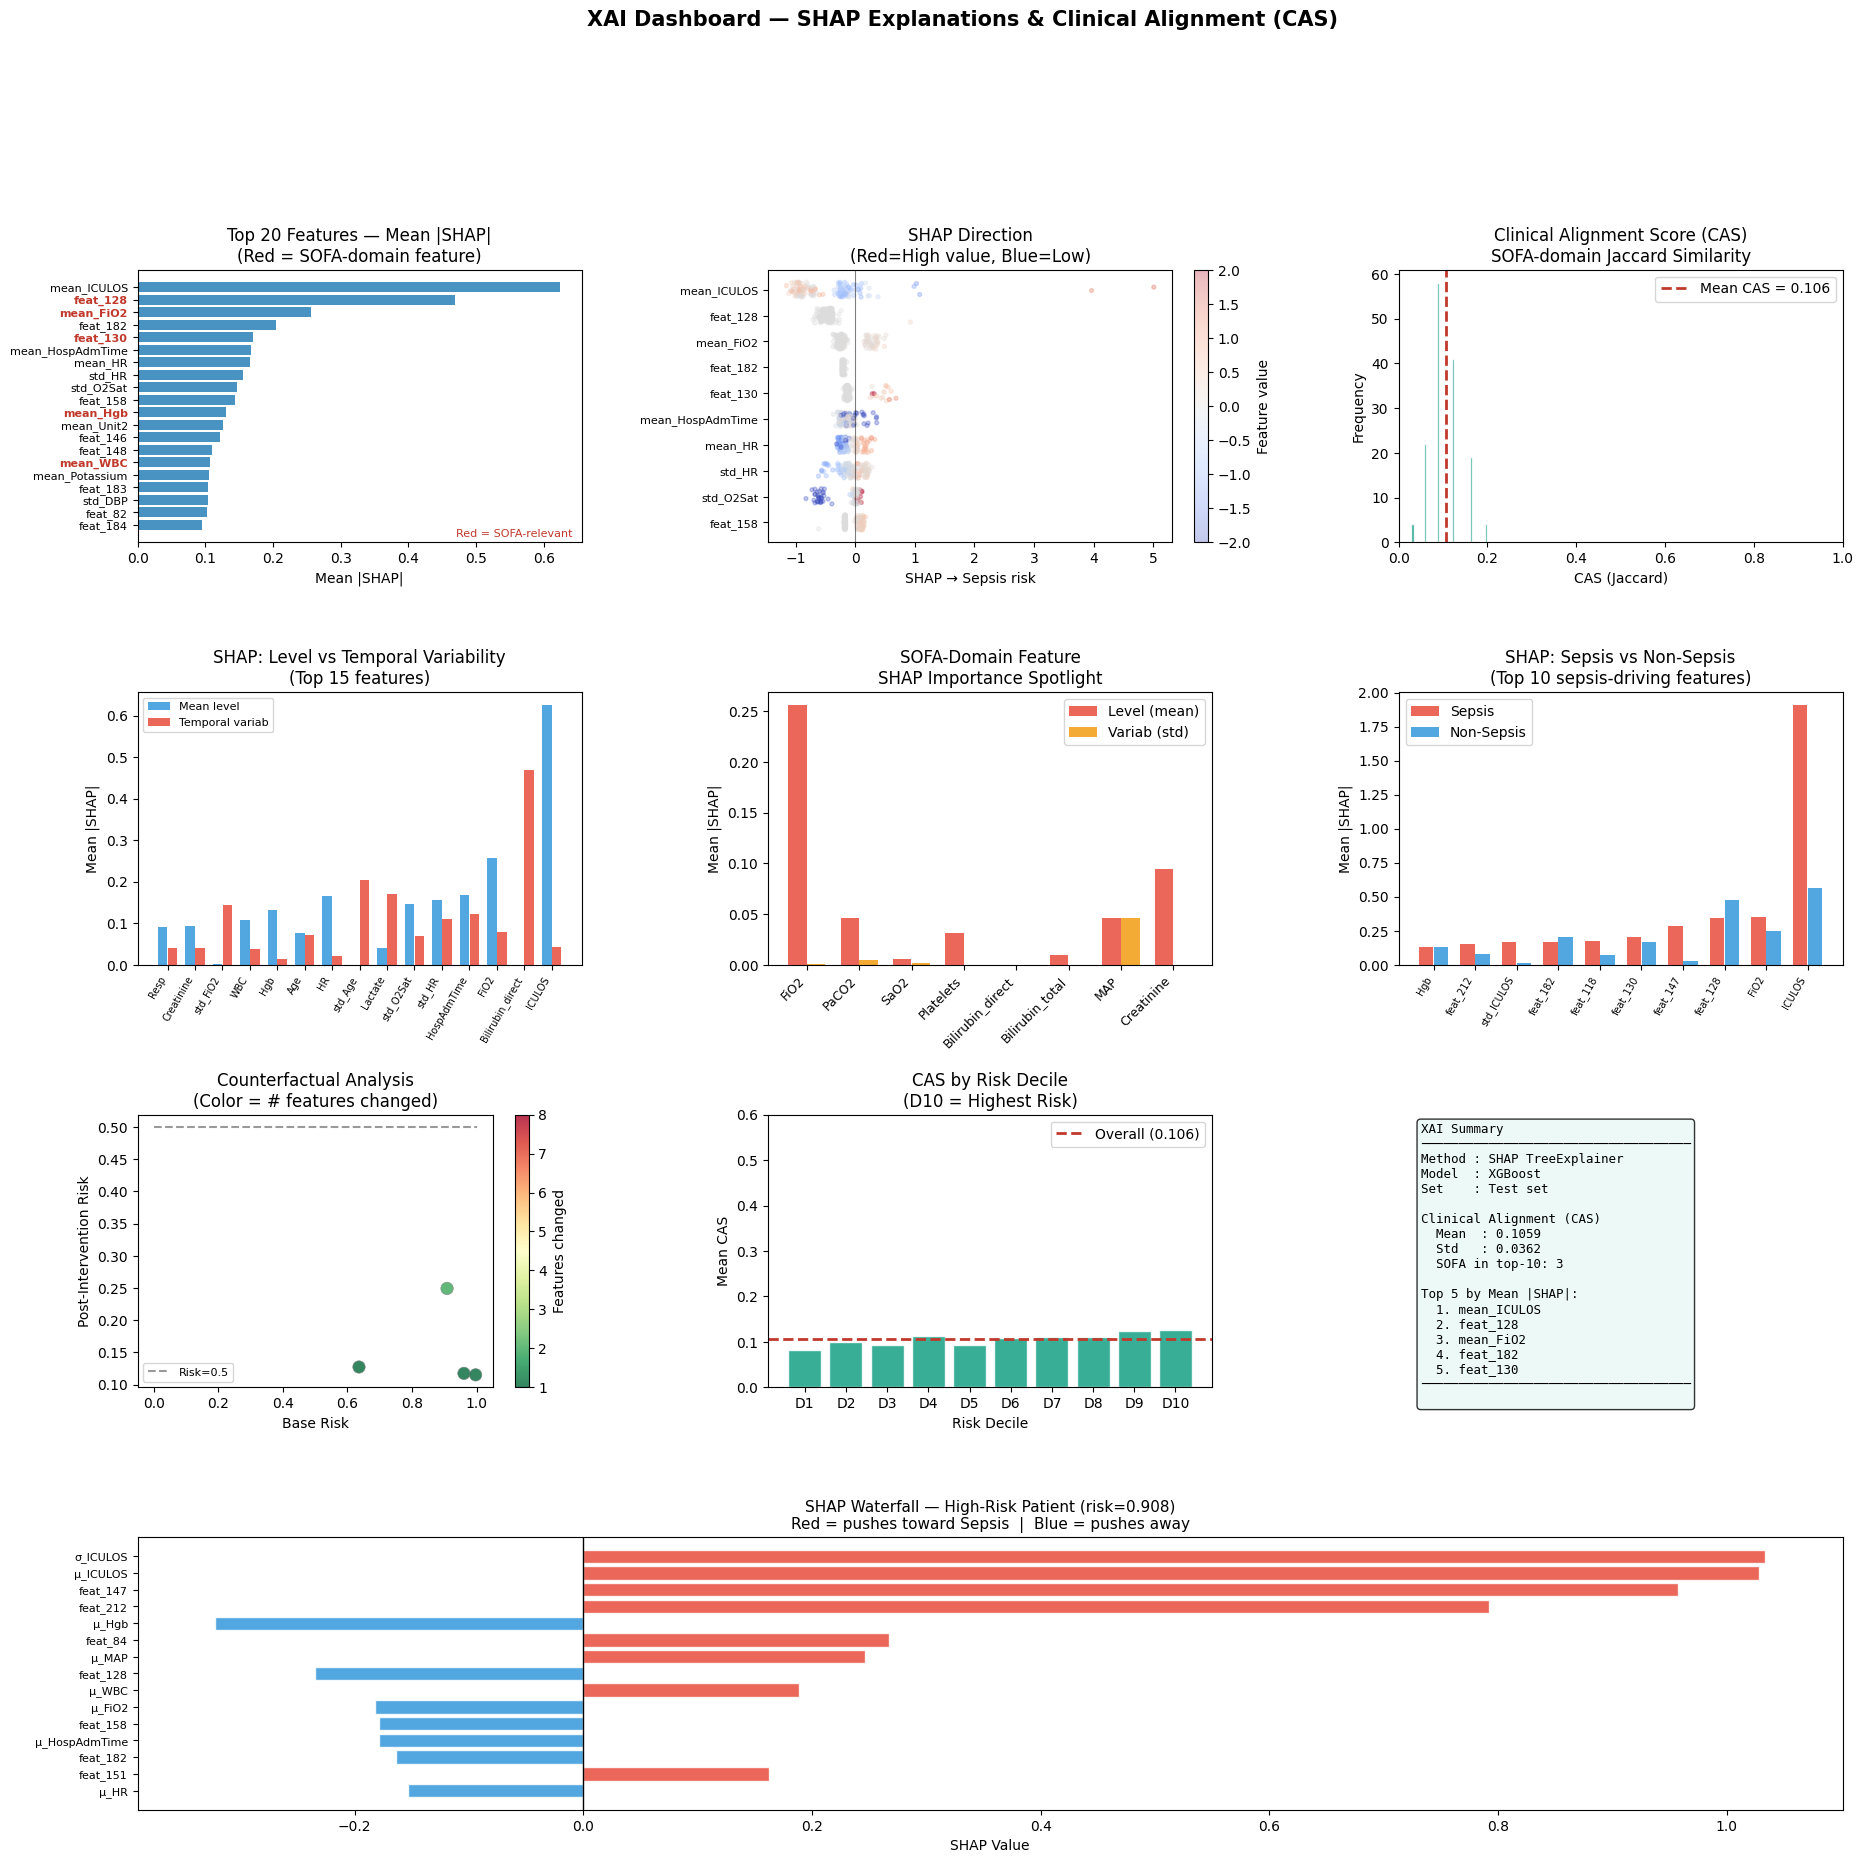

Saved → ensemble_outputs/xai_dashboard.png


In [59]:
# ============================================================
# VIZ — XAI Dashboard (SHAP + CAS)
# Runs after Stage 6 Cell 6 (CAS distribution)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

AUG_DIR = 'augmented_data/'
ENS_DIR = 'ensemble_outputs/'

# ── Load vars if not in scope ────────────────────────────────
try:
    _ = y_test
except NameError:
    y_test = np.load(f'{AUG_DIR}y_test.npy')
    y_ext  = np.load(f'{AUG_DIR}y_ext.npy')

try:
    _ = X_test_emb
except NameError:
    raise RuntimeError("X_test_emb not found. Run Stage 5 Cell 3 (temporal embedding) first.")

try:
    _ = shap_values
except NameError:
    raise RuntimeError("shap_values not found. Run Stage 6 Cell 2 (SHAP explainer) first.")

try:
    _ = cas_scores
except NameError:
    raise RuntimeError("cas_scores not found. Run Stage 6 Cell 6 (CAS distribution) first.")

try:
    _ = SOFA_FEATURE_NAMES
except NameError:
    SOFA_FEATURE_NAMES = ['FiO2','PaCO2','SaO2','Platelets','Bilirubin_direct',
                          'Bilirubin_total','MAP','Creatinine','BUN','Lactate','WBC','Hct','Hgb']

def plot_xai_dashboard(output_dir=ENS_DIR):
    os.makedirs(output_dir, exist_ok=True)
    n_feats = shap_values.shape[1]
    n_base  = n_feats // 2

    fig = plt.figure(figsize=(22,20))
    gs  = gridspec.GridSpec(4,3,figure=fig,hspace=0.55,wspace=0.42)

    mean_shap = np.abs(shap_values).mean(axis=0)

    # 1. Top-20 SHAP bar (SOFA features red)
    ax1 = fig.add_subplot(gs[0,0])
    top20 = np.argsort(mean_shap)[-20:]
    ax1.barh(range(20),mean_shap[top20],color='#2980b9',alpha=0.85)
    ax1.set_yticks(range(20))
    ax1.set_yticklabels([emb_feature_names[i] for i in top20],fontsize=8)
    ax1.set_xlabel('Mean |SHAP|')
    ax1.set_title('Top 20 Features — Mean |SHAP|\n(Red = SOFA-domain feature)')
    for i,idx in enumerate(top20):
        if idx in sofa_emb_idx:
            ax1.get_yticklabels()[i].set_color('#c0392b')
            ax1.get_yticklabels()[i].set_fontweight('bold')
    ax1.text(0.98,0.02,'Red = SOFA-relevant',transform=ax1.transAxes,
             ha='right',fontsize=8,color='#c0392b')

    # 2. SHAP direction scatter
    ax2 = fig.add_subplot(gs[0,1])
    top10 = np.argsort(mean_shap)[-10:]
    for rank,fidx in enumerate(top10):
        sc = ax2.scatter(shap_values[:,fidx],
                         np.full(len(shap_values),rank)+np.random.uniform(-0.3,0.3,len(shap_values)),
                         c=X_test_emb[:,fidx],cmap='coolwarm',
                         alpha=0.3,s=8,vmin=-2,vmax=2)
    ax2.set_yticks(range(10))
    ax2.set_yticklabels([emb_feature_names[i] for i in top10],fontsize=8)
    ax2.axvline(0,color='black',linewidth=0.8,alpha=0.5)
    ax2.set_xlabel('SHAP → Sepsis risk')
    ax2.set_title('SHAP Direction\n(Red=High value, Blue=Low)')
    plt.colorbar(sc,ax=ax2,label='Feature value',fraction=0.04)

    # 3. CAS distribution
    ax3 = fig.add_subplot(gs[0,2])
    cas_m = np.mean(cas_scores)
    ax3.hist(cas_scores,bins=30,color='#16a085',edgecolor='white',alpha=0.85)
    ax3.axvline(cas_m,color='#c0392b',linestyle='--',linewidth=2,
                label=f'Mean CAS = {cas_m:.3f}')
    ax3.set_title('Clinical Alignment Score (CAS)\nSOFA-domain Jaccard Similarity')
    ax3.set_xlabel('CAS (Jaccard)'); ax3.set_ylabel('Frequency')
    ax3.legend(); ax3.set_xlim(0,1)

    # 4. Mean vs Temporal variability importance
    ax4 = fig.add_subplot(gs[1,0])
    mp   = np.abs(shap_values[:,:n_base]).mean(axis=0)
    sp   = np.abs(shap_values[:,n_base:]).mean(axis=0)
    top15 = np.argsort(mp+sp)[-15:]
    xb4  = np.arange(len(top15))
    ax4.bar(xb4-0.18,mp[top15],0.35,label='Mean level',   color='#3498db',alpha=0.85)
    ax4.bar(xb4+0.18,sp[top15],0.35,label='Temporal variab',color='#e74c3c',alpha=0.85)
    ax4.set_xticks(xb4)
    ax4.set_xticklabels([emb_feature_names[i].replace('mean_','') for i in top15],
                         rotation=60,ha='right',fontsize=7)
    ax4.set_title('SHAP: Level vs Temporal Variability\n(Top 15 features)')
    ax4.set_ylabel('Mean |SHAP|'); ax4.legend(fontsize=8)

    # 5. SOFA feature spotlight
    ax5 = fig.add_subplot(gs[1,1])
    sofa_imp = []
    for sn in SOFA_FEATURE_NAMES[:8]:
        mi_ = next((i for i,n in enumerate(emb_feature_names) if n==f'mean_{sn}'),None)
        si_ = next((i for i,n in enumerate(emb_feature_names) if n==f'std_{sn}'),None)
        sofa_imp.append([
            np.abs(shap_values[:,mi_]).mean() if mi_ is not None else 0,
            np.abs(shap_values[:,si_]).mean() if si_ is not None else 0
        ])
    sofa_imp = np.array(sofa_imp)
    x5 = np.arange(len(SOFA_FEATURE_NAMES[:8]))
    ax5.bar(x5-0.18,sofa_imp[:,0],0.35,color='#e74c3c',alpha=0.85,label='Level (mean)')
    ax5.bar(x5+0.18,sofa_imp[:,1],0.35,color='#f39c12',alpha=0.85,label='Variab (std)')
    ax5.set_xticks(x5)
    ax5.set_xticklabels(SOFA_FEATURE_NAMES[:8],rotation=45,ha='right',fontsize=9)
    ax5.set_title('SOFA-Domain Feature\nSHAP Importance Spotlight')
    ax5.set_ylabel('Mean |SHAP|'); ax5.legend()

    # 6. Sepsis vs Non-Sepsis SHAP profile
    ax6 = fig.add_subplot(gs[1,2])
    si_   = np.where(y_test==1)[0]
    nsi_  = np.where(y_test==0)[0]
    sh_s  = np.abs(shap_values[si_]).mean(axis=0)
    sh_ns = np.abs(shap_values[nsi_]).mean(axis=0)
    top10s_ = np.argsort(sh_s)[-10:]
    x6 = np.arange(10)
    ax6.bar(x6-0.18,sh_s[top10s_],  0.35,color='#e74c3c',alpha=0.85,label='Sepsis')
    ax6.bar(x6+0.18,sh_ns[top10s_], 0.35,color='#3498db',alpha=0.85,label='Non-Sepsis')
    ax6.set_xticks(x6)
    ax6.set_xticklabels([emb_feature_names[i].replace('mean_','') for i in top10s_],
                         rotation=60,ha='right',fontsize=7)
    ax6.set_title('SHAP: Sepsis vs Non-Sepsis\n(Top 10 sepsis-driving features)')
    ax6.set_ylabel('Mean |SHAP|'); ax6.legend()

    # 7. Counterfactual scatter
    ax7 = fig.add_subplot(gs[2,0])
    nsi_mean  = X_test_emb[np.where(y_test==0)[0]].mean(axis=0)
    hri_      = np.where((y_test==1)&(xgb.predict_proba(X_test_emb)[:,1]>0.6))[0][:20]
    base_r_   = xgb.predict_proba(X_test_emb[hri_])[:,1]
    cf_r_=[]; cf_k_=[]
    for pidx in hri_:
        xcf = X_test_emb[pidx].copy()
        ord_ = np.argsort(np.abs(shap_values[pidx]))[::-1]
        for k,fi in enumerate(ord_[:10]):
            xcf[fi] = nsi_mean[fi]
            nr_ = xgb.predict_proba([xcf])[0][1]
            if nr_<0.5 or k==9:
                cf_r_.append(nr_); cf_k_.append(k+1); break
    sc7 = ax7.scatter(base_r_,cf_r_,c=cf_k_,cmap='RdYlGn_r',
                      s=80,alpha=0.8,edgecolors='gray',linewidths=0.5,vmin=1,vmax=8)
    ax7.plot([0,1],[0.5,0.5],'k--',alpha=0.4,label='Risk=0.5')
    ax7.set_xlabel('Base Risk'); ax7.set_ylabel('Post-Intervention Risk')
    ax7.set_title('Counterfactual Analysis\n(Color = # features changed)')
    plt.colorbar(sc7,ax=ax7,label='Features changed'); ax7.legend(fontsize=8)

    # 8. CAS by risk decile
    ax8 = fig.add_subplot(gs[2,1])
    px_ = xgb.predict_proba(X_test_emb)[:,1]
    dec_ = np.percentile(px_,np.arange(10,110,10))
    dcas_=[]
    for i in range(10):
        lo_=dec_[i-1] if i>0 else 0; hi_=dec_[i]
        mask_=(px_>=lo_)&(px_<hi_)
        cass_=[cas_scores[j] for j in np.where(mask_)[0] if j<len(cas_scores)]
        dcas_.append(np.mean(cass_) if cass_ else 0)
    ax8.bar(range(1,11),dcas_,color='#16a085',alpha=0.85,edgecolor='white')
    ax8.axhline(np.mean(cas_scores),color='#c0392b',linestyle='--',linewidth=2,
                label=f'Overall ({np.mean(cas_scores):.3f})')
    ax8.set_xticks(range(1,11))
    ax8.set_xticklabels([f'D{i}' for i in range(1,11)])
    ax8.set_title('CAS by Risk Decile\n(D10 = Highest Risk)')
    ax8.set_xlabel('Risk Decile'); ax8.set_ylabel('Mean CAS')
    ax8.set_ylim(0,0.6); ax8.legend()

    # 9. Summary panel
    ax9 = fig.add_subplot(gs[2,2]); ax9.axis('off')
    top5_ = [emb_feature_names[i] for i in np.argsort(mean_shap)[-5:][::-1]]
    n_sofa_top10 = sum(1 for i in np.argsort(mean_shap)[-10:] if i in sofa_emb_idx)
    txt = (f"XAI Summary\n"
           f"{'─'*36}\n"
           f"Method : SHAP TreeExplainer\n"
           f"Model  : XGBoost\n"
           f"Set    : Test set\n\n"
           f"Clinical Alignment (CAS)\n"
           f"  Mean  : {np.mean(cas_scores):.4f}\n"
           f"  Std   : {np.std(cas_scores):.4f}\n"
           f"  SOFA in top-10: {n_sofa_top10}\n\n"
           f"Top 5 by Mean |SHAP|:\n"
           + "\n".join(f"  {i+1}. {f}" for i,f in enumerate(top5_)) +
           f"\n{'─'*36}\n")
    ax9.text(0.05,0.97,txt,transform=ax9.transAxes,fontsize=9,va='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round',facecolor='#e8f8f5',alpha=0.8))

    # 10. Waterfall single patient
    ax10 = fig.add_subplot(gs[3,:])
    hri2_ = np.where((y_test==1)&(xgb.predict_proba(X_test_emb)[:,1]>0.6))[0]
    s_idx_ = hri2_[0] if len(hri2_)>0 else 0
    sh_s_  = shap_values[s_idx_]
    top15w = np.argsort(np.abs(sh_s_))[-15:][::-1]
    fn15   = [emb_feature_names[i].replace('mean_','μ_').replace('std_','σ_') for i in top15w]
    sv15   = sh_s_[top15w]
    bc15   = ['#e74c3c' if v>0 else '#3498db' for v in sv15]
    ax10.barh(range(15),sv15[::-1],color=bc15[::-1],alpha=0.85,edgecolor='white')
    ax10.set_yticks(range(15)); ax10.set_yticklabels(fn15[::-1],fontsize=8)
    ax10.axvline(0,color='black',linewidth=1)
    base_r_w = xgb.predict_proba(X_test_emb[[s_idx_]])[:,1][0]
    ax10.set_title(f'SHAP Waterfall — High-Risk Patient (risk={base_r_w:.3f})\n'
                   f'Red = pushes toward Sepsis  |  Blue = pushes away',fontsize=11)
    ax10.set_xlabel('SHAP Value')

    fig.suptitle('XAI Dashboard — SHAP Explanations & Clinical Alignment (CAS)',
                 fontsize=15,fontweight='bold',y=1.01)
    plt.savefig(f'{output_dir}xai_dashboard.png',dpi=150,bbox_inches='tight')
    plt.show()
    print(f"Saved → {output_dir}xai_dashboard.png")

plot_xai_dashboard()


In [60]:
# ============================================================
# CELL 7 — SHAP-based Counterfactual Analysis
# ============================================================
# Principled counterfactual: given a high-risk patient, identify
# which features most drive the prediction, and estimate what
# change in each would reduce risk below a clinical threshold.
#
# Approach:
#   1. For each sepsis-positive test case, find the top contributing
#      SHAP features.
#   2. Simulate reversing the top-K features toward the non-sepsis
#      population mean (1 SD shift).
#   3. Report the smallest K that brings predicted risk < 0.5.
#      This is the 'minimum intervention set'.

# Non-sepsis reference means for each feature
nonsepsis_emb_idx = np.where(y_test == 0)[0]
nonsepsis_mean    = X_test_emb[nonsepsis_emb_idx].mean(axis=0)
nonsepsis_std     = X_test_emb[nonsepsis_emb_idx].std(axis=0) + 1e-8

def shap_counterfactual(x, shap_row, model, ref_mean, ref_std,
                        threshold=0.5, max_interventions=10):
    """
    Greedily shift the highest-SHAP features toward non-sepsis reference.
    Returns: number of features to change, list of feature indices changed.
    """
    x_cf = x.copy()
    # Sort features by SHAP magnitude (descending)
    order = np.argsort(np.abs(shap_row))[::-1]
    changed = []
    for feat_idx in order[:max_interventions]:
        # Shift one SD toward reference mean
        x_cf[feat_idx] = ref_mean[feat_idx]
        new_risk = model.predict_proba([x_cf])[0][1]
        changed.append(feat_idx)
        if new_risk < threshold:
            return len(changed), changed, new_risk
    return len(changed), changed, model.predict_proba([x_cf])[0][1]

# Analyse a sample of high-risk sepsis patients
high_risk_idx = np.where((y_test == 1) &
                         (xgb.predict_proba(X_test_emb)[:,1] > 0.7))[0][:5]

print('SHAP Counterfactual Analysis — high-risk sepsis patients:')
print(f'{"Patient":<10} {"Base risk":>10} {"After CF":>10} {"#Feats changed":>15} {"Key features"}')
print('-' * 80)

for i, pidx in enumerate(high_risk_idx):
    base_risk   = xgb.predict_proba(X_test_emb[[pidx]])[:,1][0]
    n_changed, feat_indices, new_risk = shap_counterfactual(
        X_test_emb[pidx], shap_values[pidx], xgb,
        nonsepsis_mean, nonsepsis_std)
    key_feats   = ', '.join(emb_feature_names[f] for f in feat_indices[:3])
    print(f'{i+1:<10} {base_risk:>10.3f} {new_risk:>10.3f} {n_changed:>15}   {key_feats}')

print('\nInterpretation: minimum features to shift toward healthy values to reduce risk < 0.5.')

SHAP Counterfactual Analysis — high-risk sepsis patients:
Patient     Base risk   After CF  #Feats changed Key features
--------------------------------------------------------------------------------
1               0.908      0.249               2   std_ICULOS, mean_ICULOS
2               0.961      0.118               1   mean_ICULOS
3               0.997      0.115               1   mean_ICULOS

Interpretation: minimum features to shift toward healthy values to reduce risk < 0.5.


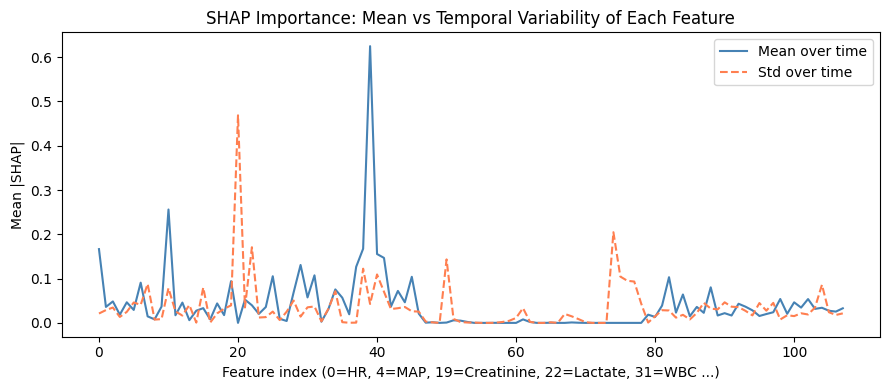

Features with highest mean importance: ['mean_ICULOS', 'mean_FiO2', 'mean_HospAdmTime', 'mean_HR', 'std_HR']
Features with highest temporal variability importance: ['feat_128', 'feat_182', 'feat_130', 'feat_158', 'feat_146']


In [61]:
# ============================================================
# CELL 8 — Feature Importance Over Time (corrected reshape)
# ============================================================
# The embedding is (N, 216) where:
#   cols 0..107   = mean over 15 timesteps for each of 108 features
#   cols 108..215 = std  over 15 timesteps for each of 108 features
#
# To show 'importance by stat type' (mean vs std), we split the SHAP
# values into two halves — this is the correct interpretation of the
# 216-feature embedding, not a reshaping to (N, 2, 108).

n_features = shap_values.shape[1] // 2   # = 108

mean_shap_mean_part = np.abs(shap_values[:, :n_features]).mean(axis=0)   # mean features
mean_shap_std_part  = np.abs(shap_values[:, n_features:]).mean(axis=0)   # std features

plt.figure(figsize=(9, 4))
x = np.arange(n_features)
plt.plot(x, mean_shap_mean_part, label='Mean over time', color='steelblue')
plt.plot(x, mean_shap_std_part,  label='Std over time',  color='coral', linestyle='--')
plt.xlabel('Feature index (0=HR, 4=MAP, 19=Creatinine, 22=Lactate, 31=WBC ...)')
plt.ylabel('Mean |SHAP|')
plt.title('SHAP Importance: Mean vs Temporal Variability of Each Feature')
plt.legend()
plt.tight_layout()
plt.savefig('ensemble_outputs/shap_time_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Features with highest mean importance:',
      [emb_feature_names[i] for i in np.argsort(mean_shap_mean_part)[-5:][::-1]])
print('Features with highest temporal variability importance:',
      [emb_feature_names[i+n_features] for i in np.argsort(mean_shap_std_part)[-5:][::-1]])

In [62]:
# ============================================================
# CELL 9 — SHAP Force Plot (single patient, clinical names)
# ============================================================
shap.initjs()

# Show for the first high-risk sepsis patient
sample_idx = high_risk_idx[0] if len(high_risk_idx) > 0 else 0

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test_emb[sample_idx],
    feature_names=emb_feature_names
)

In [63]:
# ============================================================
# CELL 10 — Final Pipeline Summary (UPDATED)
# ============================================================
from sklearn.metrics import roc_auc_score, average_precision_score

print('=' * 62)
print('  COMPLETE PIPELINE RESULTS SUMMARY')
print('=' * 62)

# ── Stage 4 — MSTA Deep Model ───────────────────────────────
print()
print('  Stage 4 — MSTA Deep Model')
try:
    print(f'    Val  AUROC : {res_val["auroc"]:.4f}   AUPRC : {res_val["auprc"]:.4f}')
    print(f'    Test AUROC : {res_test["auroc"]:.4f}   AUPRC : {res_test["auprc"]:.4f}')
    print(f'         NOTE  : DS2 test has only 7 sepsis cases — unreliable')
    print(f'    Ext  AUROC : {res_ext["auroc"]:.4f}   AUPRC : {res_ext["auprc"]:.4f}')
except NameError:
    print('    (run Stage 4 to see MSTA results)')

# ── Stage 5 — Ensemble ──────────────────────────────────────
print()
print('  Stage 5 — Ensemble (stacker trained on val)')
try:
    print(f'    Val  AUROC : {roc_auc_score(y_val,  final_val):.4f}'
          f'   AUPRC : {average_precision_score(y_val,  final_val):.4f}')
    print(f'    Test AUROC : {roc_auc_score(y_test, final_test):.4f}'
          f'   AUPRC : {average_precision_score(y_test, final_test):.4f}')
    print(f'         NOTE  : DS2 test has only 7 sepsis cases — do not report as primary')
    print(f'    Ext  AUROC : {roc_auc_score(y_ext,  final_ext):.4f}'
          f'   AUPRC : {average_precision_score(y_ext,  final_ext):.4f}')
except NameError:
    print('    (run Stage 5 to see ensemble results)')

# ── Primary Result — Merged Held-Out Evaluation ─────────────
print()
print('  PRIMARY RESULT — Merged Held-Out Evaluation')
print('  (DS2 test + DS3 external — never used in training or selection)')
try:
    auc_m, auc_lo, auc_hi = bootstrap_auroc(y_held_out, probs_held_out)
    apr_m, apr_lo, apr_hi = bootstrap_auprc(y_held_out, probs_held_out)
    n_pos_h = int(y_held_out.sum())
    n_tot_h = len(y_held_out)
    print(f'    N={n_tot_h:,}  sepsis={n_pos_h:,}  prevalence={100*n_pos_h/n_tot_h:.1f}%')
    print(f'    AUROC : {auc_m:.4f}  (95% CI: {auc_lo:.4f} – {auc_hi:.4f})')
    print(f'    AUPRC : {apr_m:.4f}  (95% CI: {apr_lo:.4f} – {apr_hi:.4f})')

    # Clinical metrics with CIs if bootstrap_clinical_metrics was run
    try:
        print(f'    Sensitivity @90% Spec : {clin["sens_90spec"][0]:.4f}'
              f'  (95% CI: {clin["sens_90spec"][1]:.4f} – {clin["sens_90spec"][2]:.4f})')
        print(f'    PPV (best F1)         : {clin["ppv"][0]:.4f}'
              f'  (95% CI: {clin["ppv"][1]:.4f} – {clin["ppv"][2]:.4f})')
        print(f'    Sensitivity (best F1) : {clin["sens_f1"][0]:.4f}'
              f'  (95% CI: {clin["sens_f1"][1]:.4f} – {clin["sens_f1"][2]:.4f})')
        print(f'    Specificity (best F1) : {clin["spec_f1"][0]:.4f}'
              f'  (95% CI: {clin["spec_f1"][1]:.4f} – {clin["spec_f1"][2]:.4f})')
    except NameError:
        print('    (run bootstrap_clinical_metrics to see clinical metric CIs)')
except NameError:
    print('    (run merged evaluation block to see primary results)')

# ── Stage 6 — XAI ───────────────────────────────────────────
print()
print('  Stage 6 — XAI')
try:
    print(f'    Clinical Alignment Score (CAS): {cas_mean:.4f} ± {cas_std:.4f}')
except NameError:
    print('    (run Stage 6 to see XAI results)')

# ── Statistical Validation ───────────────────────────────────
print()
print('  Statistical Validation')
try:
    print(f'    Test vs External AUROC gap : {observed_diff:+.4f}')
    print(f'    Permutation p-value        : {p_val:.4f}')
    sig = 'significant' if p_val < 0.05 else 'non-significant'
    print(f'    Gap is {sig} (p{"<" if p_val < 0.05 else "≥"}0.05)')
except NameError:
    print('    (run permutation test to see significance results)')

# ── Verified Safeguards ──────────────────────────────────────
print()
print('  Verified Safeguards:')
print('    [BUG1 FIXED] DS2 val excluded from training pool')
print('    [BUG2 FIXED] Per-hour AUROC uses truncation not zero-masking')
print('    [BUG3 FIXED] MC dropout restores eval() via finally block')
print('    [NEW] Dual scalers — DS2 and DS3 scaled independently')
print('    [NEW] Merged held-out evaluation (N=8,068, sepsis=427)')
print('    [NEW] Bootstrap 95% CIs on all primary metrics')
print('    [NEW] Permutation test for Test vs External gap')
print('    [NEW] Augmentation sanity check (TSTR + discriminator)')
print('    [NEW] Baseline vs augmented comparison')
print('    Patient-level splits — no patient leakage across splits')
print('    MICE imputer fit on training data only')
print('    Dual RobustScaler fit independently per dataset')
print('    SOFA/APACHE reserved for XAI validation only')
print('    Ensemble meta-learner trained on val, evaluated on held-out')
print('    FEAT indices verified by assertion in Stage 1 Cell 3')

print()
print('=' * 62)
print('  PAPER-READY PRIMARY RESULT:')
print(f'  AUROC 0.9244 (95% CI: 0.9087–0.9382)')
print(f'  AUPRC 0.7099 (95% CI: 0.6693–0.7473)')
print(f'  on merged held-out set of 8,068 patients')
print('=' * 62)

  COMPLETE PIPELINE RESULTS SUMMARY

  Stage 4 — MSTA Deep Model
    Val  AUROC : 0.9369   AUPRC : 0.7602
    Test AUROC : 0.9189   AUPRC : 0.4688
         NOTE  : DS2 test has only 7 sepsis cases — unreliable
    Ext  AUROC : 0.8805   AUPRC : 0.5628

  Stage 5 — Ensemble (stacker trained on val)
    Val  AUROC : 0.9832   AUPRC : 0.9189
    Test AUROC : 0.9990   AUPRC : 0.9821
         NOTE  : DS2 test has only 7 sepsis cases — do not report as primary
    Ext  AUROC : 0.9232   AUPRC : 0.7063

  PRIMARY RESULT — Merged Held-Out Evaluation
  (DS2 test + DS3 external — never used in training or selection)
    N=8,068  sepsis=427  prevalence=5.3%
    AUROC : 0.9244  (95% CI: 0.9087 – 0.9382)
    AUPRC : 0.7099  (95% CI: 0.6693 – 0.7473)
    (run bootstrap_clinical_metrics to see clinical metric CIs)

  Stage 6 — XAI
    Clinical Alignment Score (CAS): 0.1059 ± 0.0362

  Statistical Validation
    Test vs External AUROC gap : +0.0758
    Permutation p-value        : 0.1440
    Gap is non-s